# 05: Fixed-path Neural ODE loss comparison

**Status, 8 September:** the 42-run main matrix, eight learning-rate sensitivity runs, numerical-resolution checks and six-run hundred-block local-signature refinement are complete. Ten thousand updates define a common finite compute budget; no convergence claim follows. Main comparisons appear in §§14 to 20; §21 gives the main-matrix conclusion and §22 closes the partition refinement. Detailed procedure: `../docs/neural_ode_operator_experiments.md` §§1 to 3. Bibliographic entries: `../papers/references.bib`.

## Experiment

This notebook asks how training loss changes a learned path when one model cannot reproduce every target feature perfectly. It begins with familiar pointwise and integral losses, then introduces signature losses that compare ordered path structure. Sections 0 to 8 define the experiment, §§9 to 13 validate implementation and numerical choices, and §§14 to 22 analyze completed results.

One target path is fitted repeatedly. Model class, initialization, solver, observations, optimizer and update count remain fixed; training loss changes. Any systematic difference between fitted paths can therefore be attributed to the loss, subject to optimization variability checked across paired seeds.

Target $Y^\star:[0,1]\to\mathbb R^2$ is

$$
Y_1^\star(t)=\cos(2\pi t)+a(t)\cos(12\pi t),\qquad
Y_2^\star(t)=\sin(2\pi t)+a(t)\sin(12\pi t),
$$

where $a(t)=0.3\exp[-100(t-0.25)^2]$. Large loop gives global structure; oscillatory burst near $t=0.25$ gives local structure.

Fitted path is generated by

$$
h(0)=\eta,\qquad
\dot h(t)=f_\theta(\gamma(t),h(t)),\qquad
\widehat Y(t)=g_\phi(h(t)).
$$

Parameter vector $\Theta=(\eta,\theta,\phi)$ contains learned initial state $\eta\in\mathbb R^H$, two-layer tanh vector field $f_\theta$ and affine decoder $g_\phi:\mathbb R^H\to\mathbb R^2$. Solving differential equation produces hidden trajectory $h(t)$; decoder turns it into fitted path $\widehat Y(t)$. This Neural ODE construction follows Chen et al. (2018). Time enters through Fourier features

$$
\gamma(t)=\left[t,\sin(2^k\pi t),\cos(2^k\pi t)\right]_{k=0}^{K-1},\qquad K=5,
$$

following Tancik et al. (2020): periodic features help neural networks represent high-frequency variation. Fixed-step RK4 uses step $1/512$, matching evaluation grid. Section 10 verifies that these features let expressive model reproduce target accurately.

Compared objectives are sample MSE, elapsed-time $J_2$, smooth-path $H^1$, one global depth-four signature loss, and local depth-two signature losses on ten and one hundred blocks. Every signature objective passed a levelwise value-and-gradient audit before training.


## Execution record

Adequacy, signature audits, main closeout, learning-rate sensitivity, numerical-resolution checks and hundred-block refinement are complete. The stored study contains:

1. a 42-fit, 10,000-update main matrix over three paired seeds;
2. eight seed-zero learning-rate sensitivity fits in a separate result root;
3. Simpson, Romberg and RK4-resolution evaluations for every main fit;
4. raw and homogeneity-scaled hundred-block signature audits; and
5. six paired hundred-block fits compared with stored ten-block and pointwise controls.

Reusable code lives in `../src/pathloss/fixed_path.py` and `../src/pathloss/signatures.py`. Launch commands are in `../README.md`. Cells below inspect target, stored runs and cross-metrics.


### Budget diagnostic fixed on 26 August

Seed-zero pilot shows decreasing losses near update 5,000. Expressive clustered pair is selected because expressive capacity should approach same exact target under MSE and $J_2$, while this pair currently has largest dense-error separation. Diagnostic repeats only this pair from identical initialization for 10,000 updates. Model, clustered observations, solver, Adam learning rate and all loss definitions remain fixed.

For positive training losses $\ell_k$, define late-window ratio

$$
R=\frac{\operatorname{median}\{\ell_k:9500\leq k<10000\}}{\operatorname{median}\{\ell_k:9000\leq k<9500\}}.
$$

Loss remains materially decreasing when $R<0.95$: last 500 updates reduce median objective by more than 5% relative to preceding 500. Threshold is an engineering stopping rule fixed before diagnostic. Initial fingerprints must match across losses. Training loss at update 4,999 is compared with existing pilot to check that ARC run reproduces trajectory through original budget; failure requires a matched 5,000-update ARC run before cross-budget comparison.

Outcome meanings are fixed before run:

| outcome | action |
|---|---|
| either $R<0.95$ | 10,000 updates remain inadequate; extend diagnostic before seed sweep |
| both $R\geq0.95$ and MSE--$J_2$ dense gap shrinks | 5,000-update result contains optimization-speed effect; use accepted longer budget for every paired fit |
| both $R\geq0.95$ and dense gap persists | discrepancy effect survives budget check; freeze budget and proceed across seeds |

Representative saved models are reevaluated with RK4 step $1/1024$ before interpreting small metric differences. Material change requires finer training solver.

#### Result, 27 August

Following cell reads both histories and displays late-window medians, $R$ values and dense metrics. It is the numerical record for this diagnostic. Both runs have identical initial-state fingerprints.

Both $R$ values are below $0.95$, so 10,000 updates fail fixed stopping rule. Saved paths place largest residuals inside oscillatory event interval; current $J_2$ fit has lower error there and under every reported dense metric. This difference is not evidence of a converged loss-specific optimum while both objectives remain materially decreasing.

Local 5,000-update pilots and ARC trajectory begin from same fingerprints but diverge numerically during optimization. Cross-budget metric changes are therefore descriptive only. Stopping conclusion uses two late windows from each single ARC history and does not depend on cross-platform comparison.

#### Finite-budget decision, 27 August

Ten thousand updates are adopted as a common compute horizon rather than a convergence threshold. This changes experiment question from comparison of converged optima to comparison of what each loss learns under equal optimization effort. The late-window result remains useful: it prevents terminal differences from being described as converged loss geometry. Common evaluation metrics at fixed checkpoints are used because raw training objectives have different scales.

Following cell computes the stopping calculation directly from saved ARC histories.


In [1]:
from pathlib import Path
import json
import statistics
import pandas as pd

budget_root = Path('../results/runs/neural_ode_fixed_path_budget_10k')
rows = []
fingerprints = []
for loss in ['mse', 'j2']:
    run = budget_root / 'expressive' / 'seed0' / 'clustered' / loss
    history = json.loads((run / 'history.json').read_text())
    values = [row['train_loss'] for row in history]
    median_9000_9499 = statistics.median(values[9000:9500])
    median_9500_9999 = statistics.median(values[9500:10000])
    R = median_9500_9999 / median_9000_9499
    meta = json.loads((run / 'meta.json').read_text())
    fingerprints.append(meta['initial_fingerprint'])
    rows.append({
        'loss': loss,
        'median loss, updates 9000:9499': median_9000_9499,
        'median loss, updates 9500:9999': median_9500_9999,
        'R': R,
        'R >= 0.95': R >= 0.95,
    })

assert len(set(fingerprints)) == 1, 'paired runs did not share initialization'
pd.DataFrame(rows).set_index('loss')


,"median loss, updates 9000:9499","median loss, updates 9500:9999",R,R >= 0.95
loss,,,,
mse,0.000010,0.000007,0.652538,False
j2,0.000001,0.000001,0.879770,False


## 0. Target and observation design

First panel shows path to be fitted. Second shows where 64 training values are supplied under two observation conditions. Clustered condition places fewer observations around oscillatory event $[0.15,0.35]$.


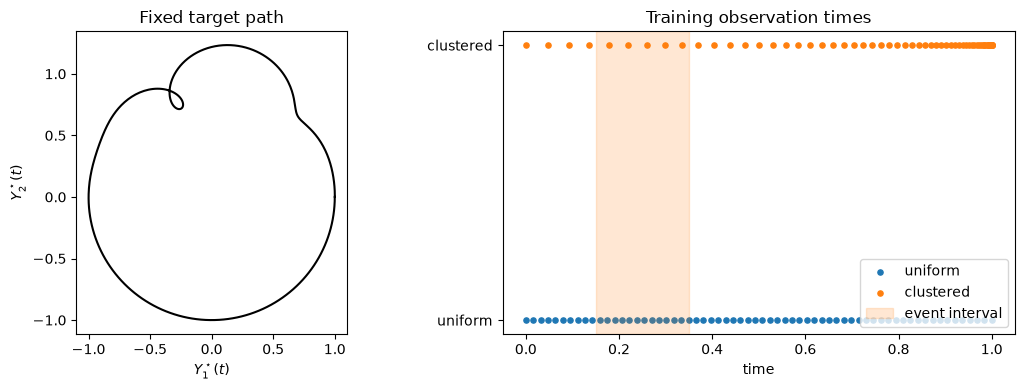

In [2]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import torch

REPO_ROOT = Path('..').resolve()
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))

from pathloss.fixed_path import fixed_target, observation_times

t_fine = torch.linspace(0.0, 1.0, 513)
target_fine = fixed_target(t_fine)
uniform_times = observation_times(64, 'uniform')
clustered_times = observation_times(64, 'clustered')

figure, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(target_fine[:, 0], target_fine[:, 1], color='black')
axes[0].set_title('Fixed target path')
axes[0].set_aspect('equal')
axes[0].set_xlabel(r'$Y_1^\star(t)$')
axes[0].set_ylabel(r'$Y_2^\star(t)$')
axes[1].scatter(uniform_times, torch.zeros_like(uniform_times), s=14, label='uniform')
axes[1].scatter(clustered_times, torch.ones_like(clustered_times), s=14, label='clustered')
axes[1].axvspan(0.15, 0.35, color='tab:orange', alpha=0.18, label='event interval')
axes[1].set_yticks([0, 1], ['uniform', 'clustered'])
axes[1].set_xlabel('time')
axes[1].set_title('Training observation times')
axes[1].legend(loc='lower right')
figure.tight_layout()


## 1. Loss comparison principle

Training selects parameters making fitted path close to target under one loss. Since losses define closeness differently, they can prefer different approximations when model capacity is limited.

Let $0=t_0<\cdots<t_{C-1}=T$ be training observation times, $Y_r=Y^\star(t_r)\in\mathbb R^{d_Y}$ with $d_Y=2$, and $\widehat Y_r=\widehat Y_\Theta(t_r)$. Residual is $e_r=\widehat Y_r-Y_r$. For discrepancy $D$, fitted parameters are

$$
\widehat\Theta_D=\operatorname*{arg\,min}_\Theta D(\widehat Y_\Theta,Y^\star).
$$

All runs within one seed, capacity and observation condition share target values, initialization, Neural ODE solver, optimizer and update count. Restricted model cannot generally make every discrepancy zero, so its fits reveal trade-offs made by each loss. Expressive model checks whether those differences disappear when target can be fitted almost exactly.

Each loss encodes a distinct meaning of closeness: equal accuracy at recorded points, elapsed-time average accuracy, value-and-tangent agreement, or agreement of ordered path features. Every fitted model is evaluated under every discrepancy and under event metrics outside its training objective.


## 2. Pointwise, elapsed-time and Sobolev losses

These losses compare increasingly rich aspects of prediction and target: recorded values, values averaged over elapsed time, then values and derivatives. They provide reference points before signature losses are introduced.

### 2.1 Pointwise MSE

MSE is the standard supervised-learning baseline based on squared error (Gneiting, 2011):

$$
D_{\mathrm{MSE}}(\widehat Y,Y)
=\frac1C\sum_{r=0}^{C-1}\|e_r\|_2^2.
$$

MSE gives every recorded target equal weight and has a simple smooth gradient. A densely observed region consequently contributes more total weight. Under uniform coverage, MSE approximates normalized squared $L^2$ error; under nonuniform coverage, it instead measures error against observation distribution. Notebook 01 derives this distinction.

### 2.2 Elapsed-time $J_2$

$J_2$ asks for average squared error per unit of elapsed time. Trapezoid weights approximate time integral from irregular observations (Davis and Rabinowitz, 1984); related time weighting for clumped observations is discussed by Rimoldini (2014). Define weights

$$
w_0=\frac{t_1-t_0}{2},\qquad
w_r=\frac{t_{r+1}-t_{r-1}}{2}\quad(1\leq r\leq C-2),\qquad
w_{C-1}=\frac{t_{C-1}-t_{C-2}}{2}.
$$

Since $\sum_r w_r=T$, define

$$
D_{J_2}(\widehat Y,Y)
=\frac1T\sum_{r=0}^{C-1}w_r\|e_r\|_2^2
\approx\frac1T\int_0^T\|\widehat Y(t)-Y(t)\|_2^2\,dt.
$$

Each residual carries half of each adjacent time gap. $J_2$ retains MSE's quadratic residual penalty and changes only measure assigned to time. It is therefore the controlled test of whether observation density changes learned approximation. On uniform grid MSE and $J_2$ differ only through endpoint half-weights.

### 2.3 Smooth-only $H^1$ loss

$H^1$ adds derivative agreement to elapsed-time value agreement. Value-plus-derivative supervision is studied by Czarnecki et al. (2017) and Cho, Ryu and Hwang (2024). It is usable here because target derivative is known analytically and Neural ODE output is differentiable.

For differentiable paths define

$$
D_{H^1}(\widehat Y,Y)
=D_{J_2}(\widehat Y,Y)
+\frac{\rho}{T}\sum_{r=0}^{C-1}w_r
\|\dot{\widehat Y}(t_r)-\dot Y(t_r)\|_2^2.
$$

Two paths may have small value error while differing in tangent, local speed or oscillation. Derivative term makes those properties part of training objective.

Scale $\rho$ is fixed before fitting. With $\bar Y^\star=T^{-1}\sum_r w_rY^\star(t_r)$, use

$$
\rho=
\frac{\sum_r w_r\|Y^\star(t_r)-\bar Y^\star\|_2^2}
{\sum_r w_r\|\dot Y^\star(t_r)\|_2^2}.
$$

This balances target value variation and derivative energy without inspecting a fitted model; it does not guarantee equal parameter-gradient magnitudes. $H^1$ is restricted to smooth experiment A. Brownian and diffusion paths are almost surely outside $H^1$, so this loss is excluded from later stochastic operator experiments.


## 3. Signature comparison: object being measured

A signature converts a path into numbers that summarize ordered increments. Level one records total changes; higher levels record how changes in different channels occur in sequence. This supplies information about path shape and ordering beyond pointwise residual size. Iterated-integral signatures originate with Chen (1957, 1958); Chevyrev and Kormilitzin (2016) give a machine-learning introduction.

Before calculation, discrete observations are joined by straight lines, producing a piecewise-linear path. Time is divided by $T$, placing it on $[0,1]$. Output-channel units change signature magnitudes at every level (Moor et al., 2020; Fermanian, 2019). Experiment A provisionally uses unit scaling because constructed outputs are dimensionless and order one. Levelwise value and gradient audit may revise this rule before signature fits; chosen rule is then frozen and applied to prediction and target. Define time-augmented path

$$
Z_Y(t)=\left(\frac{t}{T},Y(t)\right)\in\mathbb R^{d_Z},\qquad d_Z=d_Y+1.
$$

For word $w=(w_1,\ldots,w_k)\in\{1,\ldots,d_Z\}^k$, each $w_q$ selects one channel of $Z_Y$. Corresponding signature coordinate is

$$
S^w(Z_Y)
=\int_{0<u_1<\cdots<u_k<T}
dZ_Y^{w_1}(u_1)\cdots dZ_Y^{w_k}(u_k).
$$

Domain $0<u_1<\cdots<u_k<T$ forces increments into chronological order. Level $k$ tensor $S^{(k)}(Z_Y)$ contains all $d_Z^k$ words of length $k$. Mixed time-output and output-output words record timing and ordered channel interactions. Time channel is included because signature of a raw one-dimensional path contains only powers of its total increment.

### 3.1 Difference of signatures

Two constructions may sound similar: compare signatures of two paths, or take signature of their pointwise residual. This experiment maps each path into signature feature space and compares resulting vectors, consistent with signature distances and kernels (Chevyrev and Oberhauser, 2022; Salvi et al., 2021):

$$
S^{(k)}(Z_{\widehat Y})-S^{(k)}(Z_Y).
$$

This differs from taking signature of residual path $e=\widehat Y-Y$. Equality holds at level one, while level two contains cross terms:

$$
S^{(2)}(e)
=S^{(2)}(\widehat Y)+S^{(2)}(Y)
-\int_{u<v}d\widehat Y_u\otimes dY_v
-\int_{u<v}dY_u\otimes d\widehat Y_v.
$$

Thus $S(\widehat Y-Y)\neq S(\widehat Y)-S(Y)$ from level two onward. A raw univariate residual returning to its starting value has zero positive-level signature even if it is large between endpoints. Comparing $S((t,e(t)))$ with $S((t,0))$ would instead ask whether error process has temporal structure. Current experiment compares representations assigned independently to fitted and target paths because project question concerns closeness between paths themselves.

### 3.2 Time augmentation and initial-value anchor

Signature integrals depend on increments, so shifting every output value by a constant leaves signature unchanged:

$$
S((t,Y+c))=S((t,Y)).
$$

Time augmentation supplies a strictly increasing coordinate, removing nontrivial tree-like equivalence under signature uniqueness result of Hambly and Lyons (2010). Translation invariance remains. Initial-value term $\|\widehat Y(0)-Y(0)\|^2$ therefore anchors absolute output level; without it, every constant vertical translation has zero signature discrepancy.


## 4. Anchored coordinate-mean signature loss

A usable training loss must turn signature differences into one scalar and keep levels with many coordinates from dominating solely through their size. This notebook starts with following normalization. For chosen maximum level $L$, define

$$
D_{\mathrm{coord},L}(\widehat Y,Y)
=\frac1{d_Y}\|\widehat Y(0)-Y(0)\|_2^2
+\sum_{k=1}^L d_Z^{-k}
\|S^{(k)}(Z_{\widehat Y})-S^{(k)}(Z_Y)\|_2^2.
$$

Since level $k$ contains $d_Z^k$ coordinates,

$$
d_Z^{-k}\|\Delta S^{(k)}\|_2^2
=\frac1{d_Z^k}\sum_{|w|=k}|\Delta S^w|^2.
$$

Each summand is a mean squared coordinate discrepancy. Coefficient $d_Z^{-k}$ removes growth caused solely by number $d_Z^k$ of coordinates; it does not equalize numerical values or parameter gradients across levels. Squared $\ell^2$ keeps optimization form similar to MSE. Signature theory does not select these exact weights, so §9 requires a levelwise loss and gradient audit before comparative runs.

Factorial decay gives a separate scale effect. For a continuous bounded-variation path $Z$, let $|dZ^j|$ be total-variation measure of channel $j$, define $d\nu_Z=\sum_j|dZ^j|$, and set $V_Z=\nu_Z([0,T])$. Summing absolute iterated integrals over all words gives

$$
\|S^{(k)}(Z)\|_1
\leq\int_{0<u_1<\cdots<u_k<T}d\nu_Z(u_1)\cdots d\nu_Z(u_k)
=\frac{V_Z^k}{k!}.
$$

Consequently, for $\Delta S^{(k)}=S^{(k)}(Z)-S^{(k)}(\widetilde Z)$,

$$
d_Z^{-k}\|\Delta S^{(k)}\|_2^2
\leq d_Z^{-k}
\left(\frac{V_Z^k+V_{\widetilde Z}^k}{k!}\right)^2.
$$

Higher levels therefore tend to become small factorially after path scale is fixed, although early levels need not decrease when variation is large. Multiplying by factorials would impose a new weighting and could amplify noisy high levels; it is considered only after value and gradient audit.

Motivation is sensitivity to ordered path structure. MSE and $J_2$ compare residual magnitude at aligned times and do not directly compare iterated interactions. Signature loss can distinguish paths having similar average pointwise error but different loop orientation, ordering or channel interaction. Training signatures use prediction and target at same $C$ observation times with identical piecewise-linear interpolation. Dense target values remain evaluation-only.


## 5. Response-derived signature alternative

Coordinate-mean loss in §4 is easy to compute, but its chosen level coefficients have no downstream-system interpretation. This section develops an alternative meaning of closeness: two paths are close when they produce similar terminal states in every bounded-strength linear controlled system. Signature coordinates appear because they are coefficients in exact solution expansion of these systems.

Derivation has four stages: expand a controlled system response in signature coordinates (§§5.1 to 5.3), bound response difference between two drivers (§5.4), define worst-case response discrepancy (§5.5), then obtain finite loss that could be optimized (§5.6). Scaled piecewise-linear paths used here have bounded variation, so Riemann--Stieltjes integrals and signature series are well defined. This alternative is derived for interpretation and is deferred from initial training runs because application-specific response scale $r$ has not yet been chosen.


### 5.1 Path, words and controlled system

Goal is to express how a path drives a simple dynamical system. Definitions and signature expansion follow Chen (1957, 1958), Lyons, Caruana and Levy (2007), and Friz and Victoir (2010).

Let $Z:[0,T]\to\mathbb R^{d_Z}$ have channels $Z^1,\ldots,Z^{d_Z}$. A word of length $k$ is $w=(w_1,\ldots,w_k)\in\{1,\ldots,d_Z\}^k$. Its signature coordinate is

$$
S^w(Z)
=\int_{0<u_1<\cdots<u_k<T}
dZ_{u_1}^{w_1}\cdots dZ_{u_k}^{w_k}.
$$

Index $w_1$ labels earliest increment and $w_k$ latest increment. Level $k$ tensor $S^{(k)}(Z)$ collects all words of length $k$. Define coordinate $\ell^1$ norm by

$$
\|S^{(k)}(Z)\|_1=\sum_{|w|=k}|S^w(Z)|.
$$

Choose state dimension $m$ and matrices $A_1,\ldots,A_{d_Z}\in\mathbb R^{m\times m}$. Path $Z$ drives linear controlled differential equation (CDE)

$$
dH_t=\sum_{j=1}^{d_Z}A_jH_t\,dZ_t^j,\qquad H_0=h_0.
$$

Integral form is

$$
H_t=h_0+\sum_{j=1}^{d_Z}\int_0^tA_jH_u\,dZ_u^j.
$$

Matrix $A_j$ specifies response to increment in channel $j$. Fix $\|h_0\|_2=1$ and define response-strength bound

$$
\|A\|:=\max_{1\leq j\leq d_Z}\|A_j\|_{\mathrm{op}}\leq r.
$$

Parameter $r$ limits how strongly system can react to one channel increment. Channel scaling must be fixed before $r$ has meaning. Ferrucci, Perree and Lyons (2026) formulate their approximation problem with Hilbert--Schmidt tensor norms and a Frobenius norm on $A$. Present per-channel operator norm is a deliberate adaptation: it makes each word coefficient satisfy the dimension-free product bound in §5.3.


### 5.2 First two Picard iterates

Picard iteration repeatedly substitutes current approximation of $H$ into integral equation. First two steps show exactly how signature terms arise and fix ordering of path channels and matrices. Full derivation appears in Lyons, Caruana and Levy (2007) and Friz and Victoir (2010, ch. 10).

Set zeroth Picard path $H_t^{[0]}=h_0$ and recursively define

$$
H_t^{[n+1]}
=h_0+\sum_{j=1}^{d_Z}\int_0^tA_jH_u^{[n]}\,dZ_u^j.
$$

First iterate substitutes constant state $h_0$ into integral:

$$
\begin{aligned}
H_T^{[1]}
&=h_0+\sum_j\int_0^TA_jh_0\,dZ_u^j\\
&=h_0+\sum_jA_jS^j(Z)h_0.
\end{aligned}
$$

Here $S^j(Z)=Z_T^j-Z_0^j$ is coordinate for one-letter word $(j)$. Second iterate substitutes $H^{[1]}$:

$$
\begin{aligned}
H_T^{[2]}
&=h_0+\sum_j\int_0^TA_j
\left(h_0+\sum_iA_i\int_0^u dZ_v^i\,h_0\right)dZ_u^j\\
&=h_0+\sum_jA_jS^j(Z)h_0
+\sum_{i,j}A_jA_i
\left(\int_{0<v<u<T}dZ_v^i\,dZ_u^j\right)h_0\\
&=h_0+\sum_jA_jS^j(Z)h_0
+\sum_{i,j}A_jA_iS^{(i,j)}(Z)h_0.
\end{aligned}
$$

Region $0<v<u<T$ is an ordered two-dimensional simplex: it contains pairs of times for which $v$ occurs before $u$. This order comes from nested integration. For word $(i,j)$, signature reads earliest-to-latest as $(i,j)$, while matrix product is $A_jA_i$ because latest action multiplies from left.


### 5.3 Full solution expansion and convergence

Continuing Picard substitution gives one matrix and one path increment per level. Picard iterates converge to following linear-CDE signature expansion (Lyons, Caruana and Levy, 2007; Friz and Victoir, 2010, ch. 10):

$$
H_T^A(Z)
=h_0+\sum_{k=1}^{\infty}\sum_{|w|=k}
A_{w_k}\cdots A_{w_1}S^w(Z)h_0.
$$

Expansion separates machine coefficient $A_{w_k}\cdots A_{w_1}$ from path coefficient $S^w(Z)$.

For continuous bounded-variation channel $Z^j$, write $|dZ^j|$ for its total-variation measure. Define positive measure $\nu_Z$ and channelwise $\ell^1$ variation by

$$
d\nu_Z=\sum_{j=1}^{d_Z}|dZ^j|,\qquad
V_Z=\nu_Z([0,T])
=\sum_{j=1}^{d_Z}\operatorname{TV}(Z^j;[0,T]).
$$

For each word, absolute value of signed iterated integral is bounded by corresponding integral against variation measures. Summing all $d_Z^k$ words gives

$$
\begin{aligned}
\|S^{(k)}(Z)\|_1
&\leq\int_{0<u_1<\cdots<u_k<T}
d\nu_Z(u_1)\cdots d\nu_Z(u_k)\\
&=\frac1{k!}\left(\int_0^T d\nu_Z(u)\right)^k
=\frac{V_Z^k}{k!}.
\end{aligned}
$$

Last equality holds because continuous $Z$ gives atomless $\nu_Z$: product domain splits, up to diagonals of zero measure, into $k!$ disjoint regions corresponding to all time orderings. This is precise meaning of ordered-simplex volume in present argument. Bound is standard factorial decay for signatures of bounded-variation paths (Lyons, Caruana and Levy, 2007, Proposition 2.2).

Under $\|A\|\leq r$, matrix submultiplicativity gives

$$
\|A_{w_k}\cdots A_{w_1}\|_{\mathrm{op}}
\leq\prod_{q=1}^k\|A_{w_q}\|_{\mathrm{op}}\leq r^k.
$$

Therefore response series is absolutely bounded by

$$
\sum_{k=0}^{\infty}r^k\|S^{(k)}(Z)\|_1
\leq\sum_{k=0}^{\infty}\frac{(rV_Z)^k}{k!}
=e^{rV_Z}.
$$

Thus series converges absolutely, permitting termwise subtraction for two paths. Factorial decay also explains why weights $r^k$ leave sum finite for bounded-variation paths.


### 5.4 Upper bound for response difference

Let $Z$ and $\widetilde Z$ drive same matrices from same initial state. Subtracting their response expansions turns signature differences into an upper bound on terminal-state difference. This determines weights and norm used later. Define signature-coordinate difference

$$
\Delta S^w=S^w(Z)-S^w(\widetilde Z).
$$

Subtract exact expansions:

$$
H_T^A(Z)-H_T^A(\widetilde Z)
=\sum_{k=1}^{\infty}\sum_{|w|=k}
A_{w_k}\cdots A_{w_1}\Delta S^w h_0.
$$

Apply triangle inequality:

$$
\begin{aligned}
\|H_T^A(Z)-H_T^A(\widetilde Z)\|_2
&\leq\sum_{k=1}^{\infty}\sum_{|w|=k}
\|A_{w_k}\cdots A_{w_1}\|_{\mathrm{op}}
|\Delta S^w|\,\|h_0\|_2\\
&\leq\sum_{k=1}^{\infty}\sum_{|w|=k}r^k|\Delta S^w|\\
&=\sum_{k=1}^{\infty}r^k\|\Delta S^{(k)}\|_1.
\end{aligned}
$$

Weight $r^k$ appears because level-$k$ term contains exactly $k$ response matrices. Tensor $\ell^1$ norm appears because triangle inequality sums absolute contributions of all words at that level. Factorial estimate from §5.3 also gives

$$
\sum_{k=1}^{\infty}r^k\|\Delta S^{(k)}\|_1
\leq e^{rV_Z}+e^{rV_{\widetilde Z}}-2,
$$

so upper bound is finite for every pair of continuous bounded-variation paths.

Coordinate $\ell^\infty$ gives a different statement. Since level $k$ has $d_Z^k$ coordinates,

$$
\|\Delta S^{(k)}\|_1
\leq d_Z^k\|\Delta S^{(k)}\|_\infty,
$$

and therefore

$$
\|H_T^A(Z)-H_T^A(\widetilde Z)\|_2
\leq\sum_{k=1}^{\infty}(rd_Z)^k
\|\Delta S^{(k)}\|_\infty.
$$

Plain replacement of $\ell^1$ by $\ell^\infty$ while retaining weights $r^k$ would lose response upper-bound guarantee. It would emphasize largest coordinate at each level and define a different loss.


### 5.5 Worst-case response discrepancy

Ferrucci, Perree and Lyons (2026, Problem 0.1) study path representations that approximate linear CDE responses uniformly over $\|A\|\leq r$. Turning this response criterion into a distance-like comparison between two paths means taking largest terminal separation over all admissible systems.

For each state dimension $m$, take fixed unit initial vector $h_0=e_1\in\mathbb R^m$. Define

$$
d_r(Z,\widetilde Z)
=\sup_{m\geq1}
\sup_{\max_j\|A_j\|_{\mathrm{op}}\leq r}
\|H_T^A(Z)-H_T^A(\widetilde Z)\|_2.
$$

Unit norm removes arbitrary scaling of response difference by initial state magnitude. Basis vector $e_1$ is fixed because matrix family is already optimized over every admissible orientation. Supremum over $m$ permits systems large enough to expose words of arbitrary length; restricting $m$ would define a weaker, dimension-dependent discrepancy. It remains finite because §5.4 supplies a bound independent of $m$:

$$
d_r(Z,\widetilde Z)
\leq e^{rV_Z}+e^{rV_{\widetilde Z}}-2<\infty.
$$

This pairwise quantity $d_r$ is introduced here; cited paper poses related representation problem rather than this pairwise discrepancy. It measures largest terminal-state separation produced by any finite-dimensional linear controlled system with one-step response strength at most $r$. Upper bound from §5.4 holds for every admissible system, hence

$$
d_r(Z,\widetilde Z)
\leq\sum_{k=1}^{\infty}r^k\|\Delta S^{(k)}\|_1.
$$

Every individual signature coordinate can also be exposed by an admissible system. Fix word $w=(w_1,\ldots,w_k)$, take $m=k+1$, and let $E_{a,b}$ denote matrix mapping $e_b$ to $e_a$. Set

$$
A_i=r\sum_{q:w_q=i}E_{q+1,q}.
$$

For each $i$, nonzero summands in $A_i$ have distinct source and target basis vectors. Hence $A_i/r$ maps an orthonormal subset to an orthonormal subset and $\|A_i\|_{\mathrm{op}}\leq r$. Starting at $e_1$, only chronological channel sequence $w_1,\ldots,w_k$ follows complete chain

$$
e_1\longrightarrow e_2\longrightarrow\cdots\longrightarrow e_{k+1}.
$$

For word $v=(v_1,\ldots,v_k)$,

$$
e_{k+1}^{\mathsf T}A_{v_k}\cdots A_{v_1}e_1
=r^k\mathbf1_{\{v=w\}}.
$$

Products of fewer than $k$ matrices cannot reach $e_{k+1}$; products of more than $k$ vanish after reaching it because every $A_i e_{k+1}=0$. Hence final coordinate $k+1$ satisfies exactly

$$
(H_T^A(Z))_{k+1}=r^kS^w(Z),
$$

and response difference has magnitude at least $r^k|\Delta S^w|$. Taking suprema gives two-sided bracket

$$
\sup_{k\geq1}\sup_{|w|=k}r^k|\Delta S^w|
\leq d_r(Z,\widetilde Z)
\leq\sum_{k=1}^{\infty}r^k\|\Delta S^{(k)}\|_1.
$$

Thus weighted signature coordinates bound response discrepancy from below and above. Upper sum is generally larger than exact worst-case response because one admissible system need not align every word contribution simultaneously.


### 5.6 Truncation and anchor

Exact $d_r$ requires optimization over every state dimension and admissible matrix family, so it is unsuitable as direct training objective. A computable alternative keeps signature upper bound through finite depth $L$.

Full upper proxy is

$$
U_r(Z,\widetilde Z)
=\sum_{k=1}^{\infty}r^k\|\Delta S^{(k)}\|_1.
$$

Finite computation keeps levels $1$ to $L$:

$$
U_{r,L}(Z,\widetilde Z)
=\sum_{k=1}^{L}r^k\|\Delta S^{(k)}\|_1.
$$

$U_{r,L}$ is explicit in differentiable signature coordinates and inherits response upper-bound interpretation up to omitted tail $R_{r,L}$. Coordinate $\ell^1$ norm and weights $r^k$ come directly from bound in §5.4.

Truncated sum alone need not upper-bound $d_r$ because omitted levels may contribute. Correct finite-depth statement is

$$
d_r(Z,\widetilde Z)\leq U_{r,L}(Z,\widetilde Z)+R_{r,L},
$$

where

$$
R_{r,L}=\sum_{k>L}r^k\|\Delta S^{(k)}\|_1.
$$

If $V_Z,V_{\widetilde Z}\leq V$, factorial decay gives

$$
\begin{aligned}
R_{r,L}
&\leq\sum_{k>L}r^k
\left(\|S^{(k)}(Z)\|_1+\|S^{(k)}(\widetilde Z)\|_1\right)\\
&\leq2\sum_{k>L}\frac{(rV)^k}{k!}.
\end{aligned}
$$

This relates response scale $r$, path variation $V$, depth $L$, and tolerated tail error. Fixed-path inputs are piecewise linear and have finite $V$. For a rough signal such as Brownian motion represented on progressively finer meshes, piecewise-linear $1$-variation typically grows with refinement; this bound then remains correct but ceases to be mesh-stable. Rough-path $p$-variation estimates are needed for a mesh-stable stochastic statement.

Signature and controlled response use increments. For constant output translation $c$,

$$
S((t,Y+c))=S((t,Y)),
$$

so absolute level requires initial-value anchor. Computable response-derived loss is

$$
D_{r,L}(\widehat Y,Y)
=\|\widehat Y(0)-Y(0)\|_2
+\sum_{k=1}^Lr^k
\|S^{(k)}(Z_{\widehat Y})-S^{(k)}(Z_Y)\|_1.
$$

Anchor uses unsquared Euclidean norm to preserve degree-one homogeneity of response bound. A squared anchor would introduce a separate scale and would require another weight.


### 5.7 What this alternative would add

Primary sources are listed in `../papers/references.bib`; local copy of Ferrucci, Perree and Lyons (2026) is `../papers/2607.26281v1.pdf`.

$D_{r,L}$ penalizes signature coordinates using a rigorous upper bound on bounded-strength linear CDE response. Small $r$ suppresses high levels; larger $r$ retains sensitivity to higher-order ordered interactions. Factorial signature decay controls infinite tail for bounded-variation paths. Coordinate $\ell^1$ is required by this upper-bound derivation. A largest-coordinate $\ell^\infty$ loss remains possible, but carries a different interpretation unless factor $d_Z^k$ is restored.

Ferrucci, Perree and Lyons (2026) ask how depth and interval subdivision should trade off when stored representation must approximate solutions of all linear CDEs with $\|A\|\leq r$ to accuracy $\varepsilon$. Pairwise discrepancy $d_r$ and finite training loss $D_{r,L}$ above adapt that criterion to present comparison; they are derived here rather than stated in paper.

Parameter $r$ changes under channel rescaling and should come from application response scale. Initial signature experiment uses coordinate-mean $D_{\mathrm{coord},L}$ because no application-derived $r$ is fixed. Response-derived loss remains a separately labelled alternative.


## 6. Global and local signature losses

A signature loss must decide both maximum depth and interval over which features are calculated. High depth on full path retains complicated interactions across distant times. Lower depth on short intervals gives simpler summaries tied to particular path regions. This section compares those allocations while storing same number of signature coordinates. Ferrucci, Perree and Lyons (2026) motivate this depth-versus-partition question.

For $d_Y=2$, time augmentation gives three channels: normalized time, $Y_1$ and $Y_2$. Signature depth $L$ means retaining every ordered word of lengths $1$ through $L$. It refers to signature truncation, not number of Neural ODE layers. Global loss uses full interval and depth four:

$$
D_{\mathrm{global}}=D_{\mathrm{coord},4}.
$$

Levels one to four contain $3$, $3^2$, $3^3$ and $3^4$ coordinates, giving $120$ in total. Level one records channel increments. Level two records ordered pairs of increments; levels three and four record longer ordered interactions. Since integration spans $[0,T]$, one word may combine events from distant path regions. Mixed time-output words encode when output movements occur relative to elapsed time.

For local alternative, partition $0=a_0<\cdots<a_J=T$ into $J=10$ equal intervals $I_j=[a_{j-1},a_j]$. Define

$$
D_{\mathrm{local},2,10}(\widehat Y,Y)
=\frac1{d_Y}\|\widehat Y(0)-Y(0)\|_2^2
+\frac1{10}\sum_{j=1}^{10}\sum_{k=1}^{2}3^{-k}
\|S^{(k)}(Z_{\widehat Y}|_{I_j})-S^{(k)}(Z_Y|_{I_j})\|_2^2.
$$

Each depth-two block contains $3+3^2=12$ coordinates. Ten blocks therefore contain $10\times12=120$, matching global feature count. Factor $1/10$ averages interval contributions. Block index records coarse location of a mismatch. Each block retains only increments and ordered pairs within its interval, omitting higher-order within-interval features and direct words spanning separate intervals. Chen's identity can reconstruct global signature from complete signatures of consecutive segments; depth-two truncation and separate blockwise comparison discard part of that information.

Comparison asks which allocation guides fitted path more effectively: deeper cross-time structure or shallower localized structure. Equal coordinate count controls stored feature count only. Computation, gradient scale and represented information remain different and will be reported rather than assumed equal.


## 7. Evaluation discrepancies and their roles

Training loss alone cannot show what kind of fit was learned. Every model is therefore evaluated by same collection of metrics on same dense grid, including metrics it did not optimize. This reveals whether improvement is confined to training objective or changes another recognizable path property.

Every fitted path is evaluated on 513 uniform points. Dense MSE checks average sampled accuracy on common grid. Dense $J_2$ approximates elapsed-time residual energy. Dense $H^1$ checks values and tangents. Supremum error

$$
E_\infty=\max_m\|\widehat Y(\tau_m)-Y^\star(\tau_m)\|_2
$$

detects a concentrated failure hidden by averages. Local-event score

$$
E_{\mathrm{local}}
=\frac1{0.2}\int_{0.15}^{0.35}
\|\widehat Y(t)-Y^\star(t)\|_2^2\,dt
$$

measures recovery of oscillatory burst fixed before fitting. Global and local signature discrepancies are also reported for every model. Improvement only on training loss is objective recovery; improvement on supremum, local-event or another loss supplies evidence that chosen geometry changes broader fitted-path behaviour.


## 8. Experimental settings fixed before results

Settings below remain unchanged across loss comparisons. Fixing them before results prevents a loss from receiving a different model or training budget.

| factor | values |
|---|---|
| target observations | uniform; $t_r=1-(1-r/63)^3$ clustered |
| capacity | restricted $(H=2,w=16)$; expressive $(H=8,w=64)$ |
| seed | $0,1,2$ |
| primary loss | MSE; $J_2$ |
| secondary loss | $H^1$; global depth-four signature; ten-block local depth-two signature |
| updates | 10,000 fixed finite compute budget |

### 8.1 Reason for each setting

| setting | reason | check or revision criterion |
|---|---|---|
| one-path fit before operator learning | A single fixed target removes input-distribution, causality and generalization effects, making loss-dependent approximation visible before stream-to-stream model is introduced. It is a diagnostic path-fitting study rather than evidence about learned operators. | Proceed to operator task only after loss implementations, gradients and cross-metrics behave as specified here. |
| fixed two-dimensional target | Raw one-dimensional signatures collapse to functions of total increment. Two output channels create orientation and cross-channel iterated integrals. Large loop supplies global structure; localized high-frequency burst supplies a known local feature. Analytic target also permits $H^1$ supervision. | Expressive MSE adequacy must pass. Replace target if local event is invisible to independent local score or every restricted model either fits exactly or fails globally. |
| Neural ODE path parameterization | It generates a continuous differentiable path, permits derivative evaluation, and constrains approximation through hidden dimension while avoiding forecasting. | Compare solver refinements and confirm every parameter receives finite gradient. Replace parameterization if solver error or architecture failure dominates loss effects. |
| five Fourier frequencies | Target contains angular frequencies $2\pi$ and $12\pi$; dyadic features through $16\pi$ provide nearby high-frequency coordinates. Raw-time versus Fourier adequacy test evaluates this addition under matched seed, observations, optimizer and update count. Fourier model has more input parameters. | Seed-991 adequacy passed. Feature map remains fixed; revisit only if later capacities fail despite numerical convergence. |
| fixed-step RK4 with step $1/512$ | Step matches dense evaluation grid and removes adaptive-solver tolerance as a varying factor across losses. | Re-evaluate representative fits at step $1/1024$ before interpreting small loss differences. Material path or metric change requires finer training solver. |
| uniform and cubic clustered observations | Uniform grid is coverage control. $t_r=1-(1-r/63)^3$ keeps endpoints and count fixed while moving observations toward $t=1$, leaving fewer near burst at $t=0.25$. This isolates elapsed-time weighting under deliberately uneven coverage. | Record gaps, trapezoid weights and event-region count. Replace mapping if it fails to produce intended coverage contrast. |
| restricted and expressive capacities | Losses share same zero-error solution when model represents target exactly. Restricted model is intended to expose approximation trade-offs; expressive model tests disappearance near exact fit. | Expressive capacity already passes MSE adequacy. Restricted capacity is informative only if it has nonzero error while recovering broad loop. |
| full-batch Adam with matched update budget | One fixed target supplies no sampling benefit from minibatches. Full batch removes minibatch-order variation. Every paired loss receives 10,000 updates. | Report common metrics at fixed checkpoints and at update 10,000. Late-window rule already shows terminal fits need not be converged. |
| three paired seeds | Paired seeds expose optimization variability while fitting the remaining experimental window. Identical initial fingerprints permit within-seed loss contrasts. Three seeds support a consistency check, not a robustness claim. | Report every paired difference and avoid population-level claims. |
| MSE and $J_2$ as primary pair | Both use squared residuals; only time measure changes. This isolates sampling-weight mechanism before adding structural features. | Uniform fits should nearly agree. Larger separation under clustering supports intended mechanism; absence redirects effort away from weighting study. |
| smooth-only $H^1$ and target-energy $\rho$ | Target and Neural ODE are differentiable, so derivative mismatch is meaningful. Ratio $\rho$ makes value variation and derivative energy comparable using target alone. | Audit value-term, derivative-term and parameter-gradient magnitudes. Revise $\rho$ if one term is numerically inactive or dominates from initialization. |
| piecewise-linear signature path on training observations | It uses exactly target values available to MSE and $J_2$, avoiding extra dense supervision. It also matches controlled-path representation used later by Neural CDE. | Keep interpolation identical across prediction and target. Later sensitivity study may compare another fixed interpolation; main comparison changes only after that study. |
| time augmentation and initial anchor | Time channel makes ordering relative to physical time visible; anchor restores absolute output level lost by increment signatures. | Translation test must give zero unanchored signature discrepancy and positive anchored discrepancy. Raw one-dimensional degeneracy test must pass. |
| difference of signatures rather than signature of residual | It compares two independently defined path feature representations, matching central question of geometry on path space. Signature of time-augmented residual instead describes temporal structure of prediction error and is a different loss. | Keep residual-signature construction separately named. Compare it only if an error-process application motivates it. |
| coordinate-mean signature weighting | Squared $\ell^2$ gives smooth gradients comparable in form to MSE. Factor $d_Z^{-k}$ averages coordinates within level so dimension alone does not increase level weight. Anchor is averaged across output channels for same reason. | Record levelwise loss and parameter-gradient norms before training. Replace normalization if level or anchor dominates mechanically. |
| signature channel scaling | Tensor levels and response parameter $r$ change under coordinate rescaling. Unit output scaling is provisional because constructed target is dimensionless and order one. | Audit levelwise values and parameter gradients. Revise before training if a component dominates mechanically; freeze resulting rule before comparative signature runs. |
| response-derived $D_{r,L}$ deferred | Its weights have operational meaning only when $r$ bounds a relevant downstream system response. Choosing $r$ solely to improve current fit would remove that interpretation. | Introduce loss only after task supplies channel scaling, response class and $r$; report truncation tail bound. |
| global depth four versus ten local depth-two blocks | Both store 120 positive-level coordinates for $d_Z=3$, isolating allocation between depth and localization under matched storage. Ten intervals put event into a small number of explicit blocks. | Equal storage does not equalize compute or gradients; report both. Add depth or partition sensitivity only after main pair runs. |
| signature runs under uniform observations first | It prevents signature representation geometry from being confounded initially with uneven target coverage. | Add clustered signature runs only after uniform gradients and fits pass acceptance checks. |
| dense common evaluation and event interval $[0.15,0.35]$ | Common grid evaluates underlying fitted path rather than training sample locations. Event interval is symmetric about $0.25$ and ends where Gaussian envelope falls to $e^{-1}$ of its peak. | Report dense plots and event score for every loss. Revise region only before rerunning all comparisons if it fails to isolate burst. |

Every run is evaluated on 513 uniform points using dense MSE, $J_2$, $H^1$, supremum error, local $J_2$ on $[0.15,0.35]$, and global and local signature discrepancies. Equal seed and capacity must have identical saved initialization fingerprints across losses.


In [3]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from pathloss.fixed_path_study import (
    completion_report, configured_runs, load_run_registry, numerical_resolution,
)
from pathloss.provenance import load_config

REPO_ROOT = Path('..').resolve()
RESULT_ROOT = REPO_ROOT / 'results/runs/neural_ode_fixed_path'
PILOT_ROOT = REPO_ROOT / 'results/runs/neural_ode_fixed_path_signature_10k'
BUDGET_ROOT = REPO_ROOT / 'results/runs/neural_ode_fixed_path_budget_10k'
CLOSEOUT_ROOT = REPO_ROOT / 'results/runs/neural_ode_fixed_path_closeout_10k'
SENSITIVITY_ROOT = REPO_ROOT / 'results/runs/neural_ode_fixed_path_lr3e3'
CLOSEOUT_CONFIG = REPO_ROOT / 'configs/neural_ode_fixed_path_closeout_10k.yaml'
SENSITIVITY_CONFIG = REPO_ROOT / 'configs/neural_ode_fixed_path_lr3e3.yaml'

closeout_config = load_config(CLOSEOUT_CONFIG)
closeout_expected = configured_runs(closeout_config)
closeout_roots = [CLOSEOUT_ROOT, PILOT_ROOT, BUDGET_ROOT]
closeout_registry = load_run_registry(closeout_roots)
closeout_status = completion_report(closeout_expected, closeout_registry)

def load_metrics(expected, registry):
    rows = []
    for run in expected:
        if run not in registry:
            continue
        path = registry[run]
        meta = json.loads(path.read_text())
        cfg = meta['fit_config']
        rows.append({
            **run.to_dict(),
            'fingerprint': meta['initial_fingerprint'],
            'run_dir': path.parent,
            **meta['metrics'],
        })
    return pd.DataFrame(rows)

metrics = load_metrics(closeout_expected, closeout_registry)
if not metrics.empty:
    metrics = metrics.sort_values(
        ['capacity', 'seed', 'condition', 'loss'], ignore_index=True
    )
if metrics.empty:
    display(Markdown('Closeout runs are absent.'))
else:
    display(metrics)


,capacity,seed,condition,loss,lr,updates,fingerprint,run_dir,mse,j2,h1,linf,sig_global,sig_local,local_j2
0,expressive,0,clustered,j2,0.001,10000,9f86c2510cf8782df4f2419c3dd620fe6bf14d117aca0c...,/Users/davin/Desktop/Pathwise Loss/pathwise-lo...,5.597392e-05,5.598196e-05,0.007086,0.031421,NaN,NaN,2.084696e-04
1,expressive,0,clustered,mse,0.001,10000,9f86c2510cf8782df4f2419c3dd620fe6bf14d117aca0c...,/Users/davin/Desktop/Pathwise Loss/pathwise-lo...,1.151588e-04,1.153816e-04,0.012416,0.043462,NaN,NaN,4.421608e-04
2,expressive,0,uniform,h1,0.001,10000,9f86c2510cf8782df4f2419c3dd620fe6bf14d117aca0c...,/Users/davin/Desktop/Pathwise Loss/pathwise-lo...,2.533263e-06,2.533832e-06,0.000016,0.002274,0.000032,4.209112e-07,1.969062e-06
3,expressive,0,uniform,j2,0.001,10000,9f86c2510cf8782df4f2419c3dd620fe6bf14d117aca0c...,/Users/davin/Desktop/Pathwise Loss/pathwise-lo...,2.581872e-06,2.569468e-06,0.000850,0.005403,0.000051,6.576160e-06,7.887511e-06
4,expressive,0,uniform,mse,0.001,10000,9f86c2510cf8782df4f2419c3dd620fe6bf14d117aca0c...,/Users/davin/Desktop/Pathwise Loss/pathwise-lo...,1.701139e-05,1.702984e-05,0.000949,0.008716,0.000126,3.625889e-06,1.681725e-05
5,expressive,0,uniform,sig_global,0.001,10000,9f86c2510cf8782df4f2419c3dd620fe6bf14d117aca0c...,/Users/davin/Desktop/Pathwise Loss/pathwise-lo...,1.864512e-02,1.868153e-02,0.358492,0.382484,0.000386,2.253431e-02,6.930086e-02
6,expressive,0,uniform,sig_local,0.001,10000,9f86c2510cf8782df4f2419c3dd620fe6bf14d117aca0c...,/Users/davin/Desktop/Pathwise Loss/pathwise-lo...,1.296205e-03,1.298734e-03,0.048387,0.089307,0.000068,2.873913e-06,2.654829e-03
7,expressive,1,clustered,j2,0.001,10000,b45c654f6a5ecc9b4909170b93a0675520ce748c87c1d7...,/Users/davin/Desktop/Pathwise Loss/pathwise-lo...,7.734824e-05,7.745309e-05,0.009680,0.034706,0.000475,3.625869e-05,2.771645e-04
8,expressive,1,clustered,mse,0.001,10000,b45c654f6a5ecc9b4909170b93a0675520ce748c87c1d7...,/Users/davin/Desktop/Pathwise Loss/pathwise-lo...,1.321420e-04,1.323978e-04,0.013562,0.044232,0.000566,3.108894e-05,2.744768e-04
9,expressive,1,uniform,h1,0.001,10000,b45c654f6a5ecc9b4909170b93a0675520ce748c87c1d7...,/Users/davin/Desktop/Pathwise Loss/pathwise-lo...,7.448124e-05,7.449739e-05,0.000108,0.011665,0.000671,3.778321e-06,5.423758e-05


### 8.2 Comparative run checks and summary

Completion uses exact tuples $(\text{capacity},\text{seed},\text{condition},\text{loss},\eta,\text{updates})$ across closeout, pilot and budget roots. Learning-rate sensitivity has a separate root and summary. This prevents old budgets or different learning rates from satisfying a gate or entering one mean.


In [4]:
expected_frame = pd.DataFrame([run.to_dict() for run in closeout_expected])
expected_counts = expected_frame.groupby('loss').size()
completed_counts = metrics.groupby('loss').size().reindex(expected_counts.index, fill_value=0)
status = pd.DataFrame({
    'completed': completed_counts,
    'expected': expected_counts,
})
status['loss_complete'] = status['completed'] == status['expected']
display(status)
display(pd.Series({
    'exact matrix complete': closeout_status['complete'],
    'completed exact runs': closeout_status['completed'],
    'expected exact runs': closeout_status['expected'],
    'missing exact runs': len(closeout_status['missing']),
}, name='closeout'))

sensitivity_config = load_config(SENSITIVITY_CONFIG)
sensitivity_expected = configured_runs(sensitivity_config)
sensitivity_registry = load_run_registry([SENSITIVITY_ROOT])
sensitivity_status = completion_report(sensitivity_expected, sensitivity_registry)
sensitivity_metrics = load_metrics(sensitivity_expected, sensitivity_registry)
display(pd.Series({
    'exact matrix complete': sensitivity_status['complete'],
    'completed exact runs': sensitivity_status['completed'],
    'expected exact runs': sensitivity_status['expected'],
    'missing exact runs': len(sensitivity_status['missing']),
}, name='learning-rate sensitivity'))
if not sensitivity_metrics.empty:
    sensitivity_columns = [
        'capacity', 'seed', 'condition', 'loss', 'lr', 'updates',
        'mse', 'j2', 'h1', 'linf', 'local_j2', 'sig_global', 'sig_local',
    ]
    display(sensitivity_metrics[sensitivity_columns].sort_values(
        ['capacity', 'loss'], ignore_index=True
    ))

if not metrics.empty:
    fingerprint_counts = metrics.groupby(
        ['capacity', 'seed', 'condition']
    )['fingerprint'].nunique()
    mismatched = fingerprint_counts[fingerprint_counts > 1]
    display(Markdown(
        'Paired initialization check: **passed**.' if mismatched.empty
        else 'Paired initialization check: **failed**; inspect groups below.'
    ))
    if not mismatched.empty:
        display(mismatched)

    metric_columns = [
        name for name in ['mse', 'j2', 'h1', 'linf', 'local_j2', 'sig_global', 'sig_local']
        if name in metrics.columns
    ]
    summary = metrics.groupby(['capacity', 'condition', 'loss', 'lr'])[metric_columns].agg(
        ['mean', 'std', 'count']
    )
    display(summary)


,completed,expected,loss_complete
loss,,,
h1,6,6,True
j2,12,12,True
mse,12,12,True
sig_global,6,6,True
sig_local,6,6,True


exact matrix complete    True
completed exact runs       42
expected exact runs        42
missing exact runs          0
Name: closeout, dtype: object

exact matrix complete    True
completed exact runs        8
expected exact runs         8
missing exact runs          0
Name: learning-rate sensitivity, dtype: object

,capacity,seed,condition,loss,lr,updates,mse,j2,h1,linf,local_j2,sig_global,sig_local
0,expressive,0,uniform,j2,0.003,10000,3.587812e-06,3.592101e-06,0.000370,0.005952,0.000002,0.000070,1.123309e-06
1,expressive,0,uniform,mse,0.003,10000,9.576024e-07,9.574557e-07,0.000404,0.003301,0.000001,0.000006,6.808482e-07
2,expressive,0,uniform,sig_global,0.003,10000,1.947897e-02,1.951702e-02,0.363033,0.386863,0.074988,0.000396,2.301791e-02
3,expressive,0,uniform,sig_local,0.003,10000,3.076643e-04,3.082651e-04,0.024281,0.045557,0.000600,0.000040,1.529338e-06
4,restricted,0,uniform,j2,0.003,10000,5.582719e-06,5.564332e-06,0.001473,0.006297,0.000008,0.000081,1.044270e-05
5,restricted,0,uniform,mse,0.003,10000,4.430048e-06,4.435356e-06,0.001376,0.006014,0.000007,0.000010,1.938063e-06
6,restricted,0,uniform,sig_global,0.003,10000,1.841661e-02,1.845258e-02,0.387483,0.378690,0.071144,0.000429,1.948874e-02
7,restricted,0,uniform,sig_local,0.003,10000,1.038298e-03,1.040324e-03,0.070286,0.095430,0.002583,0.000053,1.935965e-06


Paired initialization check: **passed**.

mse                      \
                                               mean           std count   
capacity   condition loss       lr                                        
expressive clustered j2         0.001  8.401239e-05  3.189701e-05     3   
                     mse        0.001  1.419375e-04  3.279270e-05     3   
           uniform   h1         0.001  2.568331e-05  4.227870e-05     3   
                     j2         0.001  3.070162e-05  4.957814e-05     3   
                     mse        0.001  1.949631e-05  1.525010e-05     3   
                     sig_global 0.001  1.860351e-02  5.081400e-04     3   
                     sig_local  0.001  1.479435e-03  1.587486e-04     3   
restricted clustered j2         0.001  2.223743e-04  9.861905e-05     3   
                     mse        0.001  7.040202e-04  1.757006e-04     3   
           uniform   h1         0.001  7.111120e-07  8.003991e-07     3   
                     j2         0.001  3.187800e-05  1.301135e-05     3   
                     mse        0.001  2.030763e-05  8.220424e-06     3   
                     sig_global 0.001  1.955189e-02  1.458512e-03     3   
                     sig_local  0.001  3.829847e-03  1.359362e-03     3   

                                                 j2                      \
                                               mean           std count   
capacity   condition loss       lr                                        
expressive clustered j2         0.001  8.411675e-05  3.199142e-05     3   
                     mse        0.001  1.421707e-04  3.278670e-05     3   
           uniform   h1         0.001  2.568880e-05  4.228794e-05     3   
                     j2         0.001  3.062328e-05  4.946762e-05     3   
                     mse        0.001  1.949855e-05  1.525189e-05     3   
                     sig_global 0.001  1.863985e-02  5.091344e-04     3   
                     sig_local  0.001  1.482323e-03  1.590604e-04     3   
restricted clustered j2         0.001  2.226735e-04  9.884997e-05     3   
                     mse        0.001  7.053293e-04  1.759919e-04     3   
           uniform   h1         0.001  7.106497e-07  7.997592e-07     3   
                     j2         0.001  3.181652e-05  1.302026e-05     3   
                     mse        0.001  2.030865e-05  8.201613e-06     3   
                     sig_global 0.001  1.959008e-02  1.461361e-03     3   
                     sig_local  0.001  3.837326e-03  1.362018e-03     3   

                                             h1                      linf  \
                                           mean       std count      mean   
capacity   condition loss       lr                                          
expressive clustered j2         0.001  0.010008  0.003099     3  0.035839   
                     mse        0.001  0.014020  0.001876     3  0.043083   
           uniform   h1         0.001  0.000046  0.000053     3  0.005007   
                     j2         0.001  0.000690  0.000143     3  0.009738   
                     mse        0.001  0.000711  0.000208     3  0.007301   
                     sig_global 0.001  0.358799  0.002169     3  0.380338   
                     sig_local  0.001  0.056784  0.007384     3  0.093135   
restricted clustered j2         0.001  0.026303  0.010077     3  0.057639   
                     mse        0.001  0.041688  0.005839     3  0.084156   
           uniform   h1         0.001  0.000114  0.000051     3  0.002832   
                     j2         0.001  0.004525  0.001499     3  0.014681   
                     mse        0.001  0.004670  0.001471     3  0.014630   
                     sig_global 0.001  0.395521  0.056276     3  0.378800   
                     sig_local  0.001  0.133565  0.029931     3  0.160698   

                                       ...        local_j2                \
                                       ... count      mean           std   
capacity   condition loss       lr

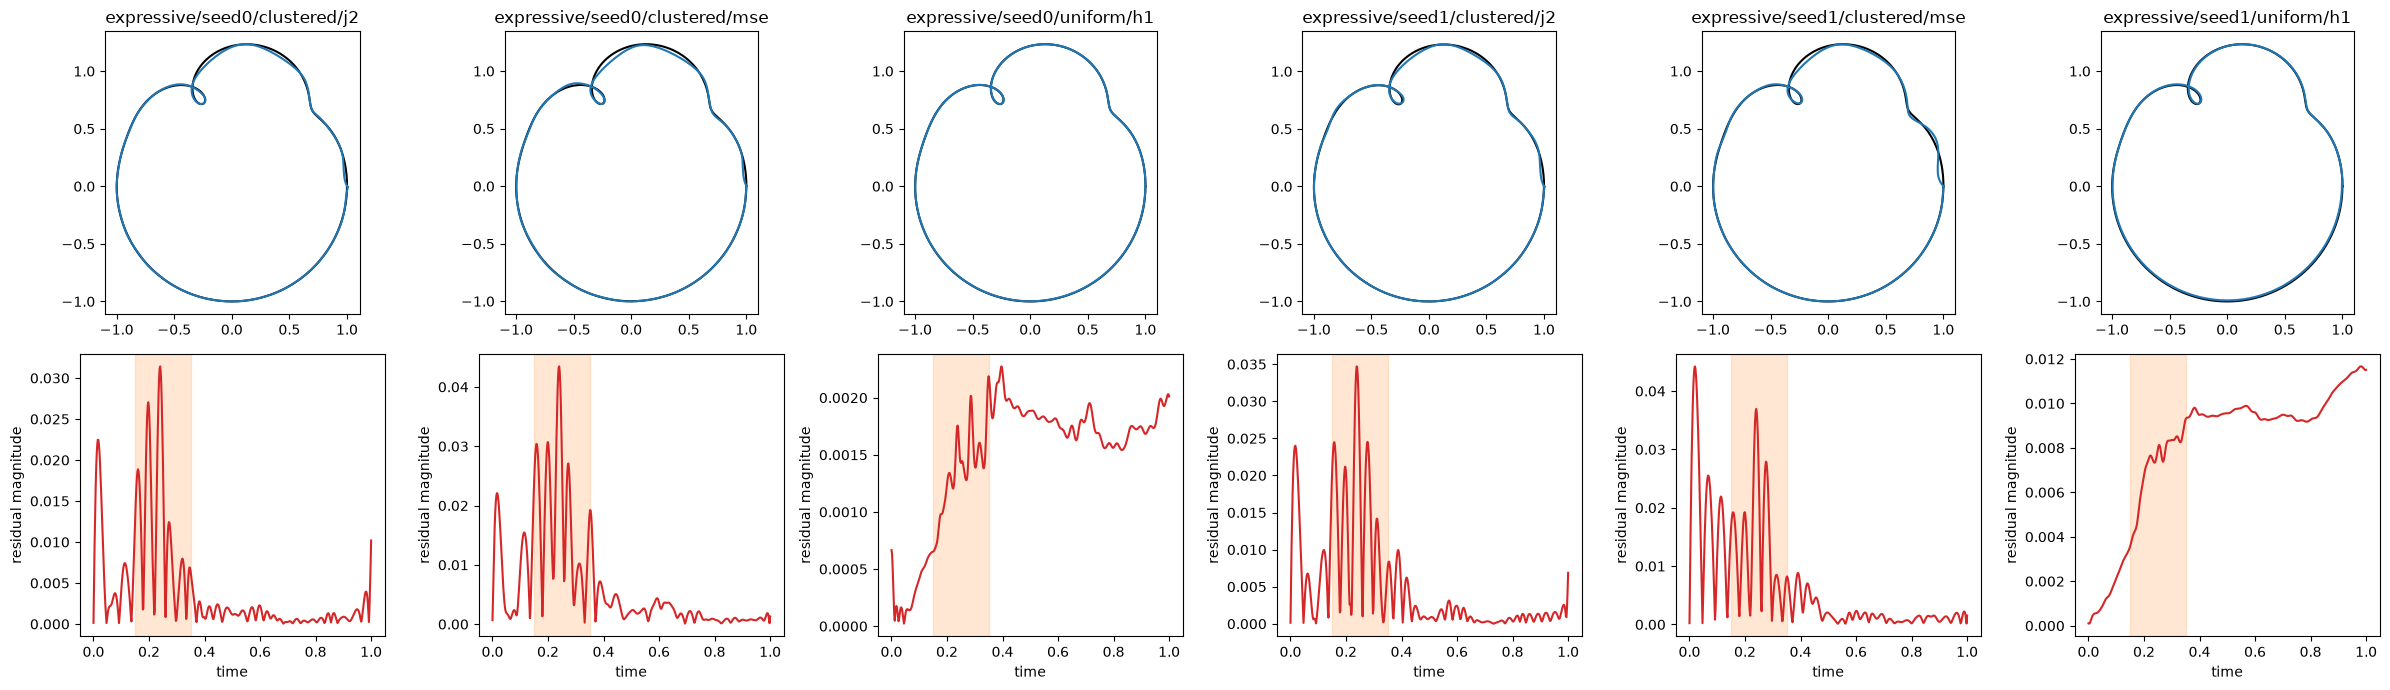

In [5]:
run_paths = sorted(path / 'paths.npz' for path in metrics.get('run_dir', []))
if run_paths:
    selected = run_paths[: min(6, len(run_paths))]
    figure, axes = plt.subplots(2, len(selected), figsize=(4 * len(selected), 7))
    axes = np.asarray(axes).reshape(2, len(selected))
    for column, path in enumerate(selected):
        arrays = np.load(path)
        label = '/'.join(path.parts[-5:-1])
        axes[0, column].plot(arrays['target'][:, 0], arrays['target'][:, 1], color='black')
        axes[0, column].plot(arrays['prediction'][:, 0], arrays['prediction'][:, 1])
        axes[0, column].set_title(label)
        axes[0, column].set_aspect('equal')
        residual = np.linalg.norm(arrays['prediction'] - arrays['target'], axis=-1)
        axes[1, column].plot(arrays['time'], residual, color='tab:red')
        axes[1, column].axvspan(0.15, 0.35, color='tab:orange', alpha=0.18)
        axes[1, column].set_xlabel('time')
        axes[1, column].set_ylabel('residual magnitude')
    figure.tight_layout()


### 8.3 Signature scaling audit

Before signature training, compare anchor and level contributions together with parameter-gradient norms. Audit diagnoses optimization geometry; it does not force equal gradients, which would define a different loss. Audit inspects unused seed 991 at initialization rather than comparative performance.

#### Result, 28 August

All recorded values and aggregate parameter-gradient norms are finite and nonzero. Global loss has large discrepancies at levels two to four, while gradient norm decreases strongly with depth. Local loss is initially dominated by anchor gradient; depth-two gradient is small but nonzero. This is accepted as a property to measure through checkpointed training rather than removed by post-hoc factorial or anchor reweighting.

Unit output scaling is frozen because time is normalized, target outputs are dimensionless and order one, and audit shows no overflow, nonfinite value or zero total gradient. Acceptance means both objectives are trainable enough for pilot; it does not assert balanced levels. Pilot checkpoint metrics determine whether structural terms become active after anchor error falls.


In [6]:
signature_audit_file = PILOT_ROOT / 'signature_audit/signature_audit.json'
if signature_audit_file.exists():
    signature_audit = json.loads(signature_audit_file.read_text())['audit']
    audit_rows = []
    for representation, specification in signature_audit['representations'].items():
        for component, values in specification['components'].items():
            audit_rows.append({
                'representation': representation,
                'depth': specification['depth'],
                'intervals': specification['intervals'],
                'feature_count': specification['feature_count'],
                'component': component,
                **values,
            })
    display(pd.DataFrame(audit_rows))
else:
    display(Markdown('Signature audit has not been run.'))


,representation,depth,intervals,feature_count,component,value,parameter_gradient_l2
0,global,4,1,120,anchor,0.908185,1.460440
1,global,4,1,120,level_1,0.000350,0.019986
2,global,4,1,120,level_2,2.690859,0.044041
3,global,4,1,120,level_3,3.028183,0.004044
4,global,4,1,120,level_4,3.095771,0.000151
5,global,4,1,120,total,9.723349,1.461222
6,local,2,10,120,anchor,0.908185,1.460440
7,local,2,10,120,level_1,0.137551,0.015119
8,local,2,10,120,level_2,0.005977,0.000027
9,local,2,10,120,total,1.051713,1.460521


## 9. Acceptance before interpretation

Loss comparison is interpretable only after confirming that model can represent target, paired runs begin identically, gradients reach every parameter and numerical approximations are stable. Required checks are:

1. Fourier adequacy file reports improvement over raw time and expressive dense MSE at most $10^{-3}$.
2. Initial fingerprints match across losses within every capacity and seed.
3. Every parameter receives finite gradient.
4. Training loss decreases, dense fitted paths are finite, and common checkpoint metrics are recorded.
5. Representative fitted paths and reported metrics are stable when reevaluated with RK4 step $1/1024$.
6. Before signature training, straight-line and concatenation checks validate signature coordinates; translation and anchor tests validate absolute-level handling; levelwise loss and gradient magnitudes are recorded.

Results and interpretation are added only after these checks pass.

Prediction fixed in advance: under uniform observations MSE and $J_2$ differ by two endpoint half-weights only, so their fits should agree closely. Separation is expected under clustered observations.


## 10. Fourier adequacy result, 23 August

This preliminary run tests model representation before comparing losses. Expressive model was trained once with raw time and once with Fourier time features. Capacity label, seed, observations, optimizer and update count match; Fourier model has additional input features and therefore more parameters. Comparison decides whether adopted representation is adequate rather than whether equal-size architectures differ.

Expressive model $(H=8,w=64)$ was trained under uniform-observation MSE for 5,000 updates using unused seed 991. Adjacent cell reads and displays every adequacy metric from `adequacy/adequacy.json`. Raw scalar time fails the pre-fixed dense-error threshold, while Fourier time features pass it and are therefore retained.

Adequacy gate passes. Fourier features remain in experiment A. Expressive model provides intended near-exact-fit capacity control. This pilot compares time representation rather than path losses; seed 991 is excluded from comparative results.


raw_dense_mse              0.006149
fourier_dense_mse           0.00001
max_dense_mse                 0.001
fourier_improves               True
expressive_fit_adequate        True
passed                         True
Name: adequacy, dtype: object

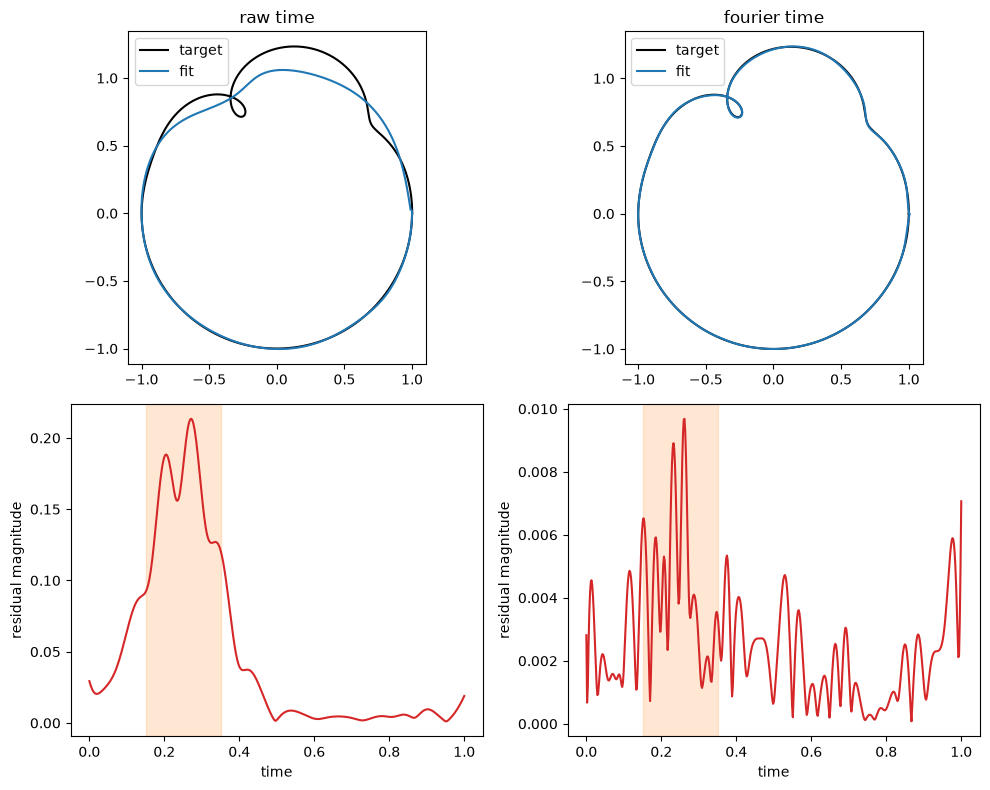

In [7]:
adequacy_root = RESULT_ROOT / 'adequacy'
adequacy_file = adequacy_root / 'adequacy.json'
if adequacy_file.exists():
    display(pd.Series(json.loads(adequacy_file.read_text()), name='adequacy'))
    figure, axes = plt.subplots(2, 2, figsize=(10, 8))
    for column, representation in enumerate(['raw_time', 'fourier_time']):
        arrays = np.load(adequacy_root / representation / 'paths.npz')
        axes[0, column].plot(arrays['target'][:, 0], arrays['target'][:, 1], color='black', label='target')
        axes[0, column].plot(arrays['prediction'][:, 0], arrays['prediction'][:, 1], label='fit')
        axes[0, column].set_title(representation.replace('_', ' '))
        axes[0, column].set_aspect('equal')
        axes[0, column].legend()
        residual = np.linalg.norm(arrays['prediction'] - arrays['target'], axis=-1)
        axes[1, column].plot(arrays['time'], residual, color='tab:red')
        axes[1, column].axvspan(0.15, 0.35, color='tab:orange', alpha=0.18)
        axes[1, column].set_xlabel('time')
        axes[1, column].set_ylabel('residual magnitude')
    figure.tight_layout()
else:
    display(Markdown('Adequacy output is absent.'))


## 11. Uniform signature pilot result, 29 August

Eight seed-zero runs completed: four losses in each capacity, all with 10,000 updates and uniform observations. Initialization fingerprints match within each capacity. Every stored path and metric is finite. Adjacent solver-check cell shows that finer RK4 reevaluation leaves the qualitative rankings unchanged.

MSE and $J_2$ fits reproduce target closely in both capacities. Pure global signature training recovers broad loop but misses localized oscillation. At this pilot stage, the fit could not be interpreted as path selected by global signature geometry: within each capacity, at least one pointwise-trained model has a lower global signature discrepancy on both training grid and dense evaluation grid than global-signature-trained model. Its parameters are therefore a feasible point with a better value of same training objective. Global run is an optimization failure under common finite budget. Checkpoints show global signature discrepancy continuing to fall while pointwise error stays flat or increases later in training, consistent with poorly conditioned optimization along directions weakly constrained by truncated representation.

Local signature training gives a different result. In each capacity it finishes with a lower dense local signature discrepancy than both pointwise-trained fits, while pointwise, derivative and event-region errors remain larger. Under chosen depth-two ten-block representation, fitted path can therefore rank closer in signature features while remaining farther from target pointwise. Expressive capacity reduces this gap substantially; restricted local fit remains visibly less accurate. Local objective and pointwise errors are still decreasing at update 10,000, so terminal values describe finite-budget learning rather than a converged optimum.

This pilot was read first as a learning-dynamics experiment, following 27 August meeting notes. Its checkpoints compare which losses recover broad loop, localized event and signature features early under equal compute. The result motivated the paired-seed closeout and learning-rate sensitivity arm in §§14–19. Global warm-start was not added; later common-objective evaluation already established finite-budget optimization failure. Pure signature losses remain probes of induced path geometry, while a combined pointwise and signature loss would define a separate future experiment.


In [8]:
import statistics

loss_order = ['mse', 'j2', 'sig_global', 'sig_local']
pilot_rows = []
for capacity in ['restricted', 'expressive']:
    fingerprints = []
    for loss in loss_order:
        run = PILOT_ROOT / capacity / 'seed0' / 'uniform' / loss
        meta = json.loads((run / 'meta.json').read_text())
        history = json.loads((run / 'history.json').read_text())
        values = [row['train_loss'] for row in history]
        fingerprints.append(meta['initial_fingerprint'])
        pilot_rows.append({
            'capacity': capacity,
            'training loss': loss,
            'late R': statistics.median(values[9500:10000])
                / statistics.median(values[9000:9500]),
            **json.loads((run / 'metrics.json').read_text()),
        })
    assert len(set(fingerprints)) == 1, f'{capacity} initialization mismatch'

pilot_metrics = pd.DataFrame(pilot_rows).set_index(['capacity', 'training loss'])
display(pilot_metrics[[
    'late R', 'mse', 'j2', 'h1', 'linf', 'local_j2', 'sig_global', 'sig_local'
]])

ranking_rows = []
for capacity in ['restricted', 'expressive']:
    group = pilot_metrics.loc[capacity]
    pointwise = group.loc[['mse', 'j2']]
    for representation in ['sig_global', 'sig_local']:
        ranking_rows.append({
            'capacity': capacity,
            'representation': representation,
            'signature-trained discrepancy': group.loc[representation, representation],
            'best pointwise-trained discrepancy': pointwise[representation].min(),
            'ratio': group.loc[representation, representation]
                / pointwise[representation].min(),
        })
display(pd.DataFrame(ranking_rows).set_index(['capacity', 'representation']))


late R       mse        j2        h1      linf  \
capacity   training loss                                                     
restricted mse            0.829805  0.000012  0.000012  0.003030  0.009145   
           j2             0.823876  0.000047  0.000047  0.002860  0.013118   
           sig_global     0.950644  0.020962  0.021003  0.459767  0.414188   
           sig_local      0.937436  0.005120  0.005130  0.165464  0.173320   
expressive mse            0.931688  0.000017  0.000017  0.000949  0.008716   
           j2             1.138412  0.000003  0.000003  0.000850  0.005403   
           sig_global     0.957256  0.018645  0.018682  0.358492  0.382484   
           sig_local      0.860603  0.001296  0.001299  0.048387  0.089307   

                          local_j2  sig_global  sig_local  
capacity   training loss                                   
restricted mse            0.000019    0.000021   0.000012  
           j2             0.000026    0.000356   0.000015  
           sig_global     0.079764    0.000466   0.021689  
           sig_local      0.008415    0.000171   0.000011  
expressive mse            0.000017    0.000126   0.000004  
           j2             0.000008    0.000051   0.000007  
           sig_global     0.069301    0.000386   0.022534  
           sig_local      0.002655    0.000068   0.000003

signature-trained discrepancy  \
capacity   representation                                  
restricted sig_global                           0.000466   
           sig_local                            0.000011   
expressive sig_global                           0.000386   
           sig_local                            0.000003   

                           best pointwise-trained discrepancy      ratio  
capacity   representation                                                 
restricted sig_global                                0.000021  22.402266  
           sig_local                                 0.000012   0.936635  
expressive sig_global                                0.000051   7.597766  
           sig_local                                 0.000004   0.792609

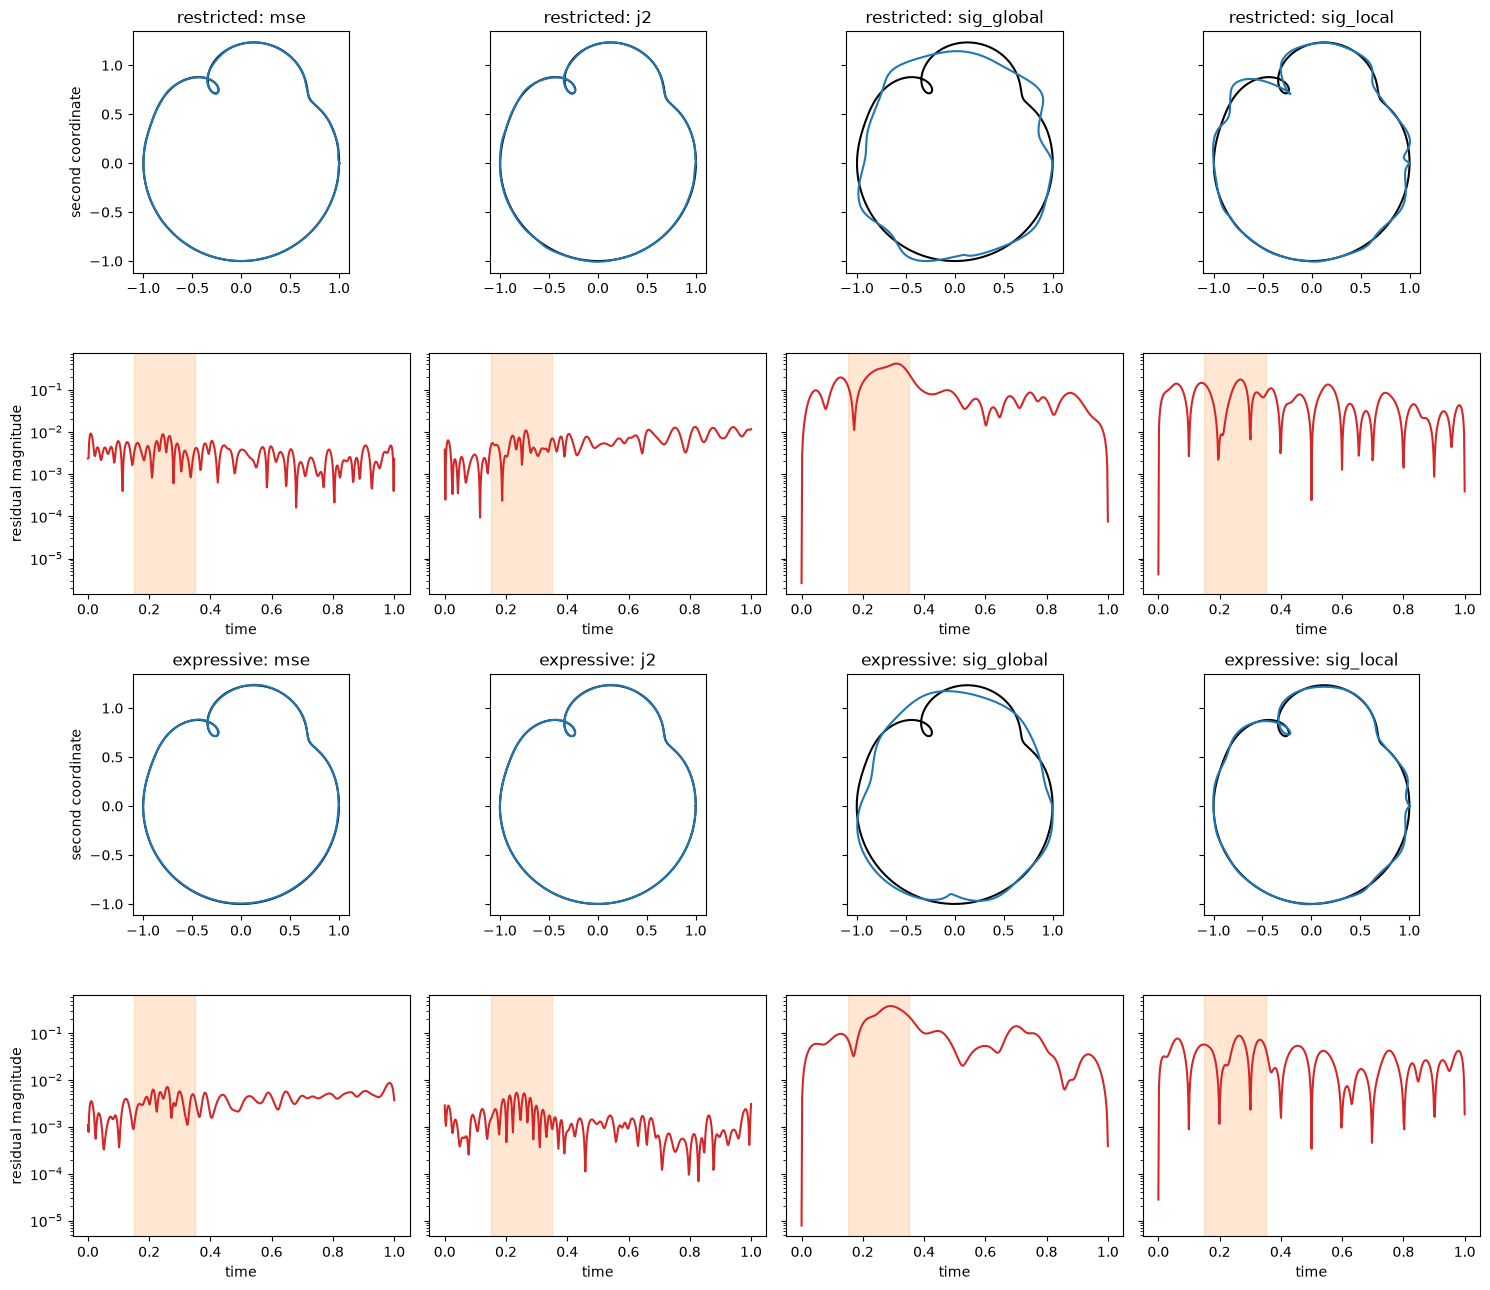

In [9]:
figure, axes = plt.subplots(4, 4, figsize=(15, 13), sharex='row', sharey='row')
for capacity_index, capacity in enumerate(['restricted', 'expressive']):
    for loss_index, loss in enumerate(loss_order):
        run = PILOT_ROOT / capacity / 'seed0' / 'uniform' / loss
        arrays = np.load(run / 'paths.npz')
        path_axis = axes[2 * capacity_index, loss_index]
        residual_axis = axes[2 * capacity_index + 1, loss_index]
        path_axis.plot(arrays['target'][:, 0], arrays['target'][:, 1], color='black')
        path_axis.plot(arrays['prediction'][:, 0], arrays['prediction'][:, 1], color='tab:blue')
        path_axis.set_aspect('equal')
        path_axis.set_title(f'{capacity}: {loss}')
        residual = np.linalg.norm(arrays['prediction'] - arrays['target'], axis=-1)
        residual_axis.plot(arrays['time'], residual, color='tab:red')
        residual_axis.axvspan(0.15, 0.35, color='tab:orange', alpha=0.18)
        residual_axis.set_yscale('log')
        residual_axis.set_xlabel('time')
    axes[2 * capacity_index, 0].set_ylabel('second coordinate')
    axes[2 * capacity_index + 1, 0].set_ylabel('residual magnitude')
figure.tight_layout()


In [10]:
import torch
from pathloss.fixed_path import (
    LatentNeuralODE, evaluate_fixed_path, fixed_path_loss, fixed_target,
    h1_balance, observation_times,
)

solver_rows = []
training_objective_rows = []
for capacity in ['restricted', 'expressive']:
    for loss in loss_order:
        run = PILOT_ROOT / capacity / 'seed0' / 'uniform' / loss
        meta = json.loads((run / 'meta.json').read_text())
        cfg = meta['fit_config']
        model = LatentNeuralODE(
            hidden=cfg['hidden'], width=cfg['width'],
            n_fourier=cfg['n_fourier'], max_step=1 / 1024,
        )
        model.load_state_dict(torch.load(run / 'model.pt', map_location='cpu', weights_only=True))
        model.eval()
        observed_time = observation_times(cfg['n_target'], cfg['condition'])
        observed_target = fixed_target(observed_time)
        with torch.no_grad():
            observed_prediction = model(observed_time)
        training_objective_rows.append({
            'capacity': capacity, 'training loss': loss,
            'global signature on training grid': float(fixed_path_loss(
                'sig_global', observed_time, observed_prediction, observed_target,
                signature_output_scale=cfg['signature_output_scale'],
                signature_global_depth=cfg['signature_global_depth'],
            )),
            'local signature on training grid': float(fixed_path_loss(
                'sig_local', observed_time, observed_prediction, observed_target,
                signature_output_scale=cfg['signature_output_scale'],
                signature_local_depth=cfg['signature_local_depth'],
                signature_local_intervals=cfg['signature_local_intervals'],
            )),
        })
        time = torch.linspace(0, 1, cfg['n_fine'])
        refined, _ = evaluate_fixed_path(
            model, n_fine=cfg['n_fine'], rho=h1_balance(time, fixed_target(time)),
            signature_output_scale=cfg['signature_output_scale'],
            signature_global_depth=cfg['signature_global_depth'],
            signature_local_depth=cfg['signature_local_depth'],
            signature_local_intervals=cfg['signature_local_intervals'],
        )
        saved = json.loads((run / 'metrics.json').read_text())
        relative_changes = {
            name: abs(refined[name] - saved[name]) / max(abs(saved[name]), 1e-30)
            for name in saved
        }
        solver_rows.append({
            'capacity': capacity, 'training loss': loss,
            'maximum relative metric change': max(relative_changes.values()),
        })
display(pd.DataFrame(solver_rows).set_index(['capacity', 'training loss']))
display(pd.DataFrame(training_objective_rows).set_index(['capacity', 'training loss']))


maximum relative metric change
capacity   training loss                                
restricted mse                                  0.000280
           j2                                   0.000173
           sig_global                           0.000008
           sig_local                            0.000067
expressive mse                                  0.000352
           j2                                   0.000081
           sig_global                           0.000160
           sig_local                            0.000038

global signature on training grid  \
capacity   training loss                                      
restricted mse                                     0.000019   
           j2                                      0.000358   
           sig_global                              0.000139   
           sig_local                               0.000144   
expressive mse                                     0.000120   
           j2                                      0.000049   
           sig_global                              0.000082   
           sig_local                               0.000060   

                          local signature on training grid  
capacity   training loss                                    
restricted mse                                    0.000008  
           j2                                     0.000013  
           sig_global                             0.020979  
           sig_local                              0.000007  
expressive mse                                    0.000002  
           j2                                     0.000006  
           sig_global                             0.021875  
           sig_local                              0.000002

## 12. Learning dynamics

Meeting notes from 27 August make finite-budget learning dynamics a primary outcome. Analysis below uses saved checkpoints only; it introduces no additional training. Question is which aspects of target each loss recovers first under same model, initialization, observations, optimizer and update count.

Predefined common metrics are dense MSE, $J_2$, $H^1$, supremum error, event-region $J_2$, and both signature discrepancies. One additional descriptive score separates background loop from event. Let $e(t)=\|\widehat Y(t)-Y^\star(t)\|_2^2$, event interval $I=[0.15,0.35]$, and background $I^c=[0,0.15]\cup[0.35,1]$. Define

$$
E_{I}=\frac{1}{0.2}\int_I e(t)\,\mathrm dt,\qquad
E_{I^c}=\frac{1}{0.8}\int_{I^c} e(t)\,\mathrm dt.
$$

$E_I$ reproduces intended event score from saved dense paths up to evaluation-grid differences. $E_{I^c}$ is post-run descriptive analysis, so it supports interpretation of broad-loop recovery but no confirmatory claim. Curves use identical axes and logarithmic error scales.


In [11]:
import torch
from pathloss.norms import quadrature_weights
from pathloss.signatures import anchored_coordinate_mean_components

checkpoint_updates = [0, 100, 500, 1000, 2500, 5000, 7500, 10000]
dynamics_rows = []
level_rows = []
for capacity in ['restricted', 'expressive']:
    for loss in loss_order:
        run = PILOT_ROOT / capacity / 'seed0' / 'uniform' / loss
        checkpoint_metrics = {
            row['updates_completed']: row['metrics']
            for row in json.loads((run / 'checkpoints.json').read_text())
        }
        arrays = np.load(run / 'checkpoint_paths.npz')
        time = arrays['time']
        target = arrays['target']
        event = (time >= 0.15) & (time <= 0.35)
        left = time <= 0.15
        right = time >= 0.35
        for update in checkpoint_updates:
            prediction = arrays[f'prediction_updates_{update:05d}']
            squared_error = np.sum((prediction - target) ** 2, axis=-1)
            event_j2 = float(
                np.sum(quadrature_weights(time[event]) * squared_error[event]) / 0.2
            )
            background_j2 = float((
                np.sum(quadrature_weights(time[left]) * squared_error[left])
                + np.sum(quadrature_weights(time[right]) * squared_error[right])
            ) / 0.8)
            dynamics_rows.append({
                'capacity': capacity, 'training loss': loss, 'update': update,
                'event_j2_dense': event_j2,
                'background_j2_dense': background_j2,
                **checkpoint_metrics[update],
            })

            tensor_time = torch.from_numpy(time)
            tensor_prediction = torch.from_numpy(prediction)
            tensor_target = torch.from_numpy(target)
            for representation, depth, intervals in [
                ('global', 4, 1), ('local', 2, 10),
            ]:
                components = anchored_coordinate_mean_components(
                    tensor_time, tensor_prediction, tensor_target,
                    depth=depth, intervals=intervals, output_scale=1.0,
                )
                for component, value in components.items():
                    level_rows.append({
                        'capacity': capacity, 'training loss': loss,
                        'update': update, 'representation': representation,
                        'component': component, 'value': float(value),
                    })

dynamics = pd.DataFrame(dynamics_rows)
level_dynamics = pd.DataFrame(level_rows)
display(dynamics.head())


,capacity,training loss,update,event_j2_dense,background_j2_dense,mse,j2,h1,linf,sig_global,sig_local,local_j2
0,restricted,mse,0,1.352474,1.208580,1.244862,1.242912,2.261801,1.536628,10.130486,1.326404,1.358040
1,restricted,mse,100,1.033355,0.666217,0.745280,0.744030,1.618976,1.419434,10.584644,1.127680,1.037753
2,restricted,mse,500,0.638086,0.380269,0.434496,0.434064,1.132371,1.153399,8.510195,0.365014,0.640339
3,restricted,mse,1000,0.027226,0.003606,0.008413,0.008378,0.259914,0.252673,0.241940,0.031163,0.027275
4,restricted,mse,2500,0.012780,0.001154,0.003493,0.003498,0.128213,0.159228,0.049882,0.004298,0.012799


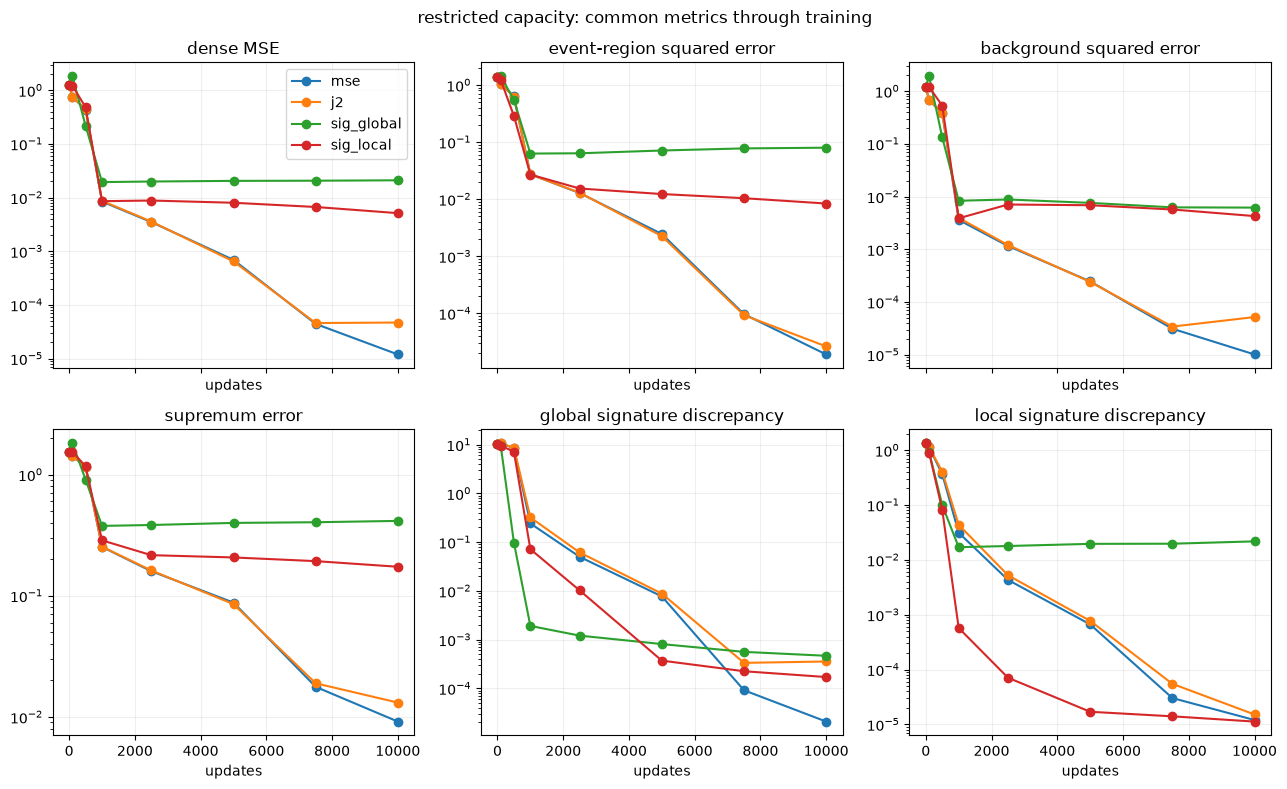

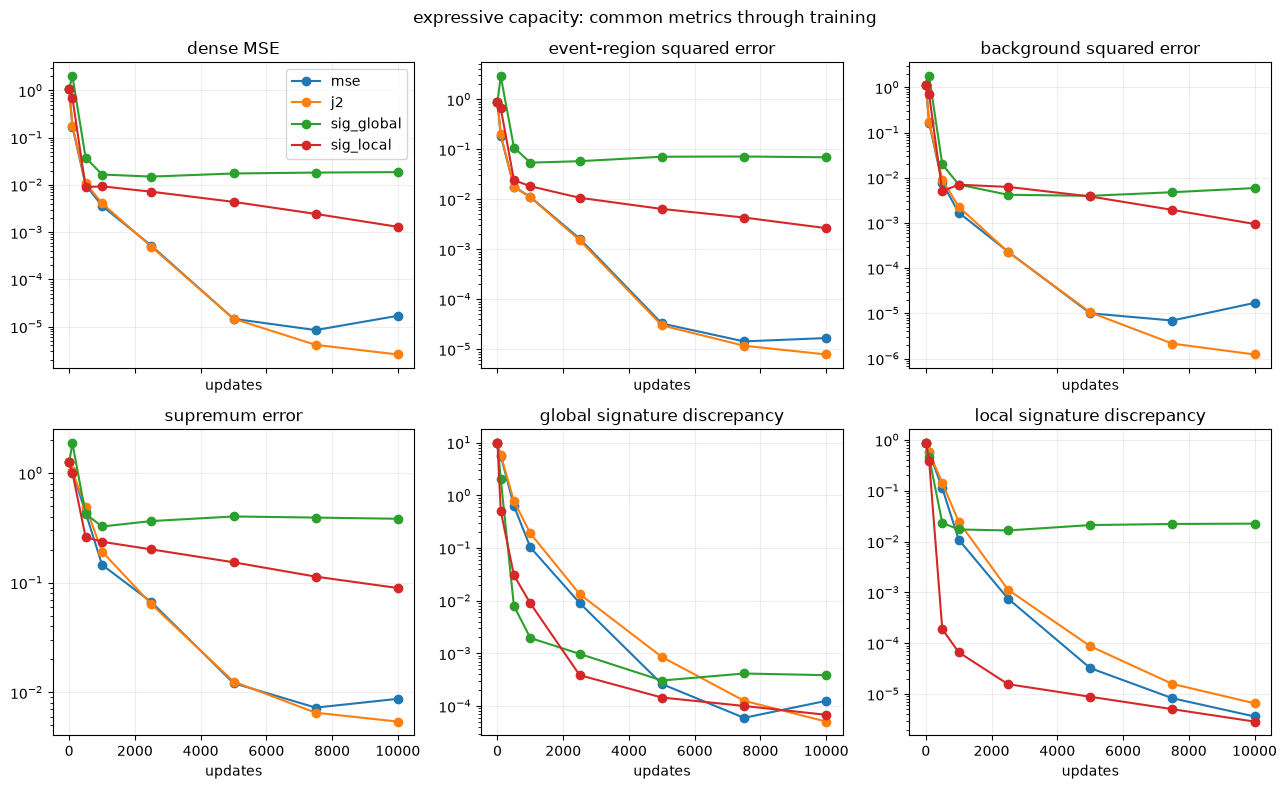

In [12]:
metric_panels = [
    ('mse', 'dense MSE'),
    ('event_j2_dense', 'event-region squared error'),
    ('background_j2_dense', 'background squared error'),
    ('linf', 'supremum error'),
    ('sig_global', 'global signature discrepancy'),
    ('sig_local', 'local signature discrepancy'),
]
colors = {
    'mse': 'tab:blue', 'j2': 'tab:orange',
    'sig_global': 'tab:green', 'sig_local': 'tab:red',
}
for capacity in ['restricted', 'expressive']:
    figure, axes = plt.subplots(2, 3, figsize=(13, 8), sharex=True)
    capacity_rows = dynamics[dynamics['capacity'] == capacity]
    for axis, (metric, title) in zip(axes.flat, metric_panels):
        for loss in loss_order:
            rows = capacity_rows[capacity_rows['training loss'] == loss]
            axis.plot(
                rows['update'], rows[metric].clip(lower=1e-12),
                marker='o', color=colors[loss], label=loss,
            )
        axis.set_yscale('log')
        axis.set_title(title)
        axis.set_xlabel('updates')
        axis.grid(alpha=0.2)
    axes[0, 0].legend()
    figure.suptitle(f'{capacity} capacity: common metrics through training')
    figure.tight_layout()


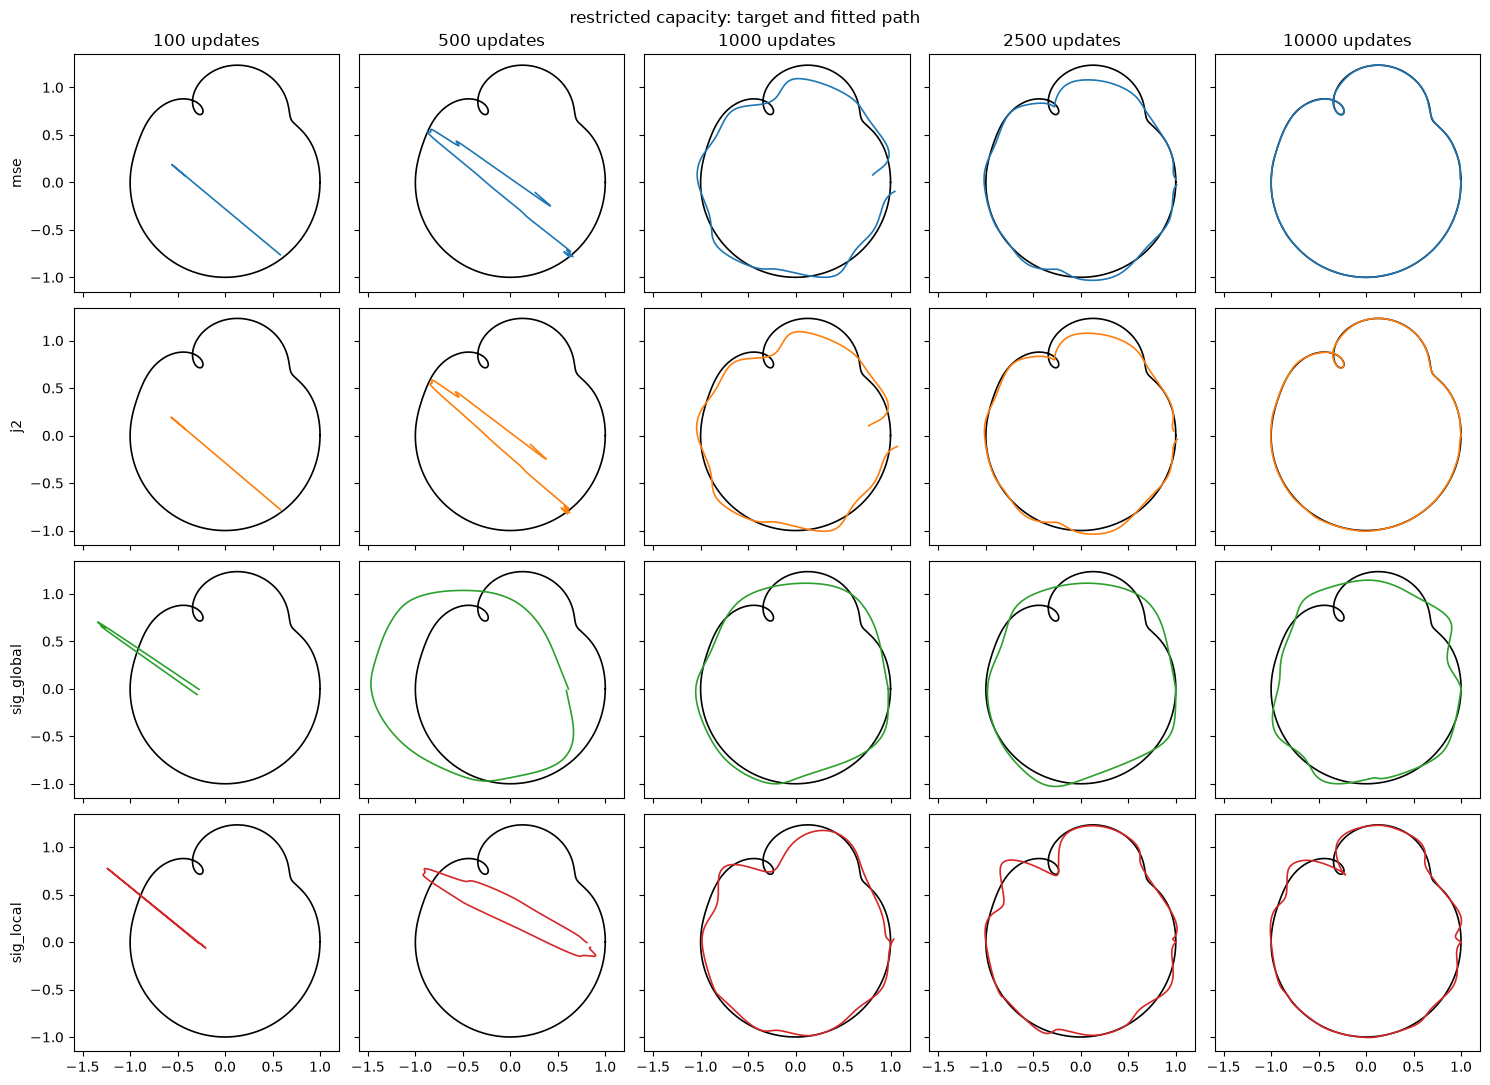

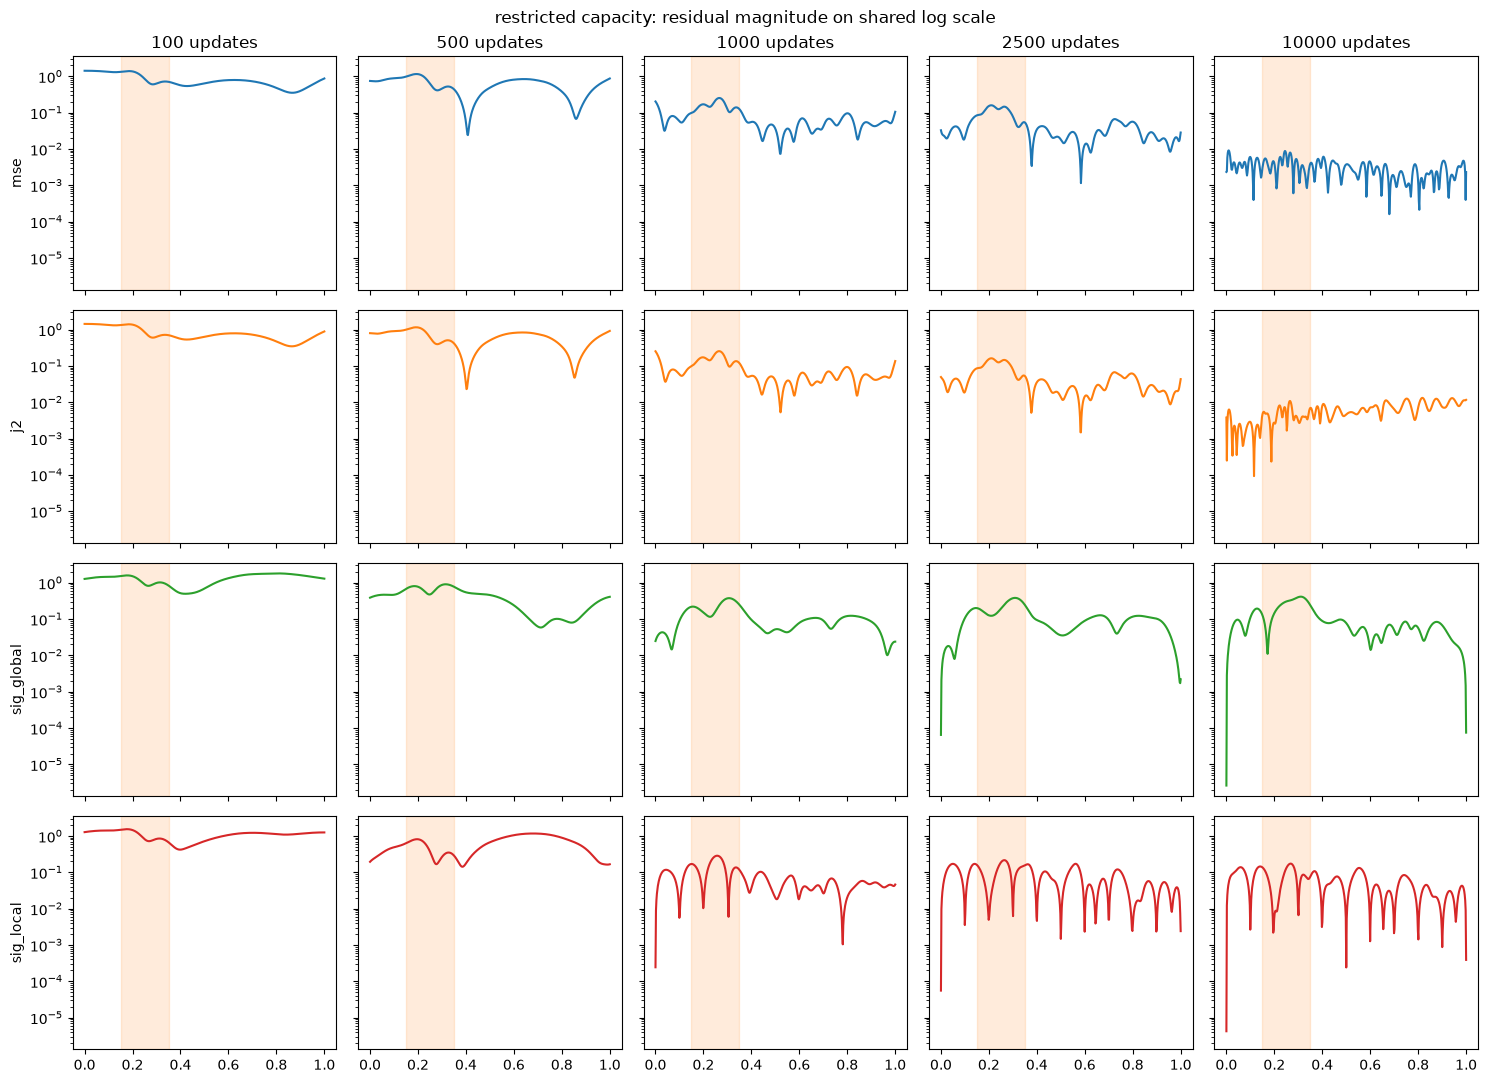

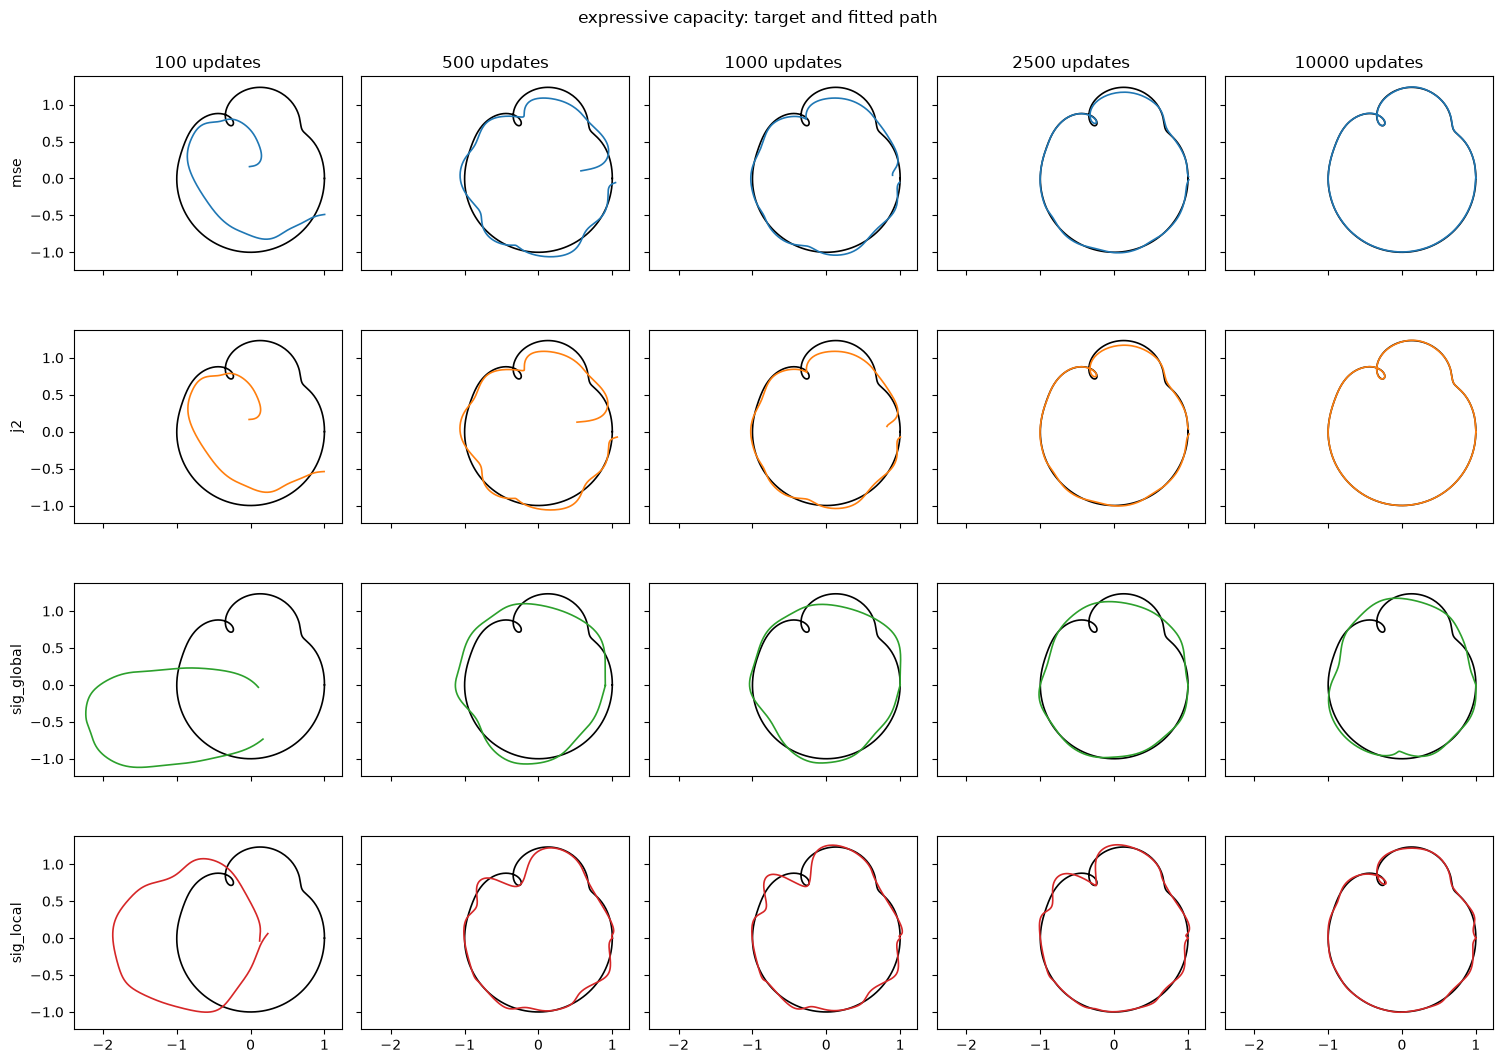

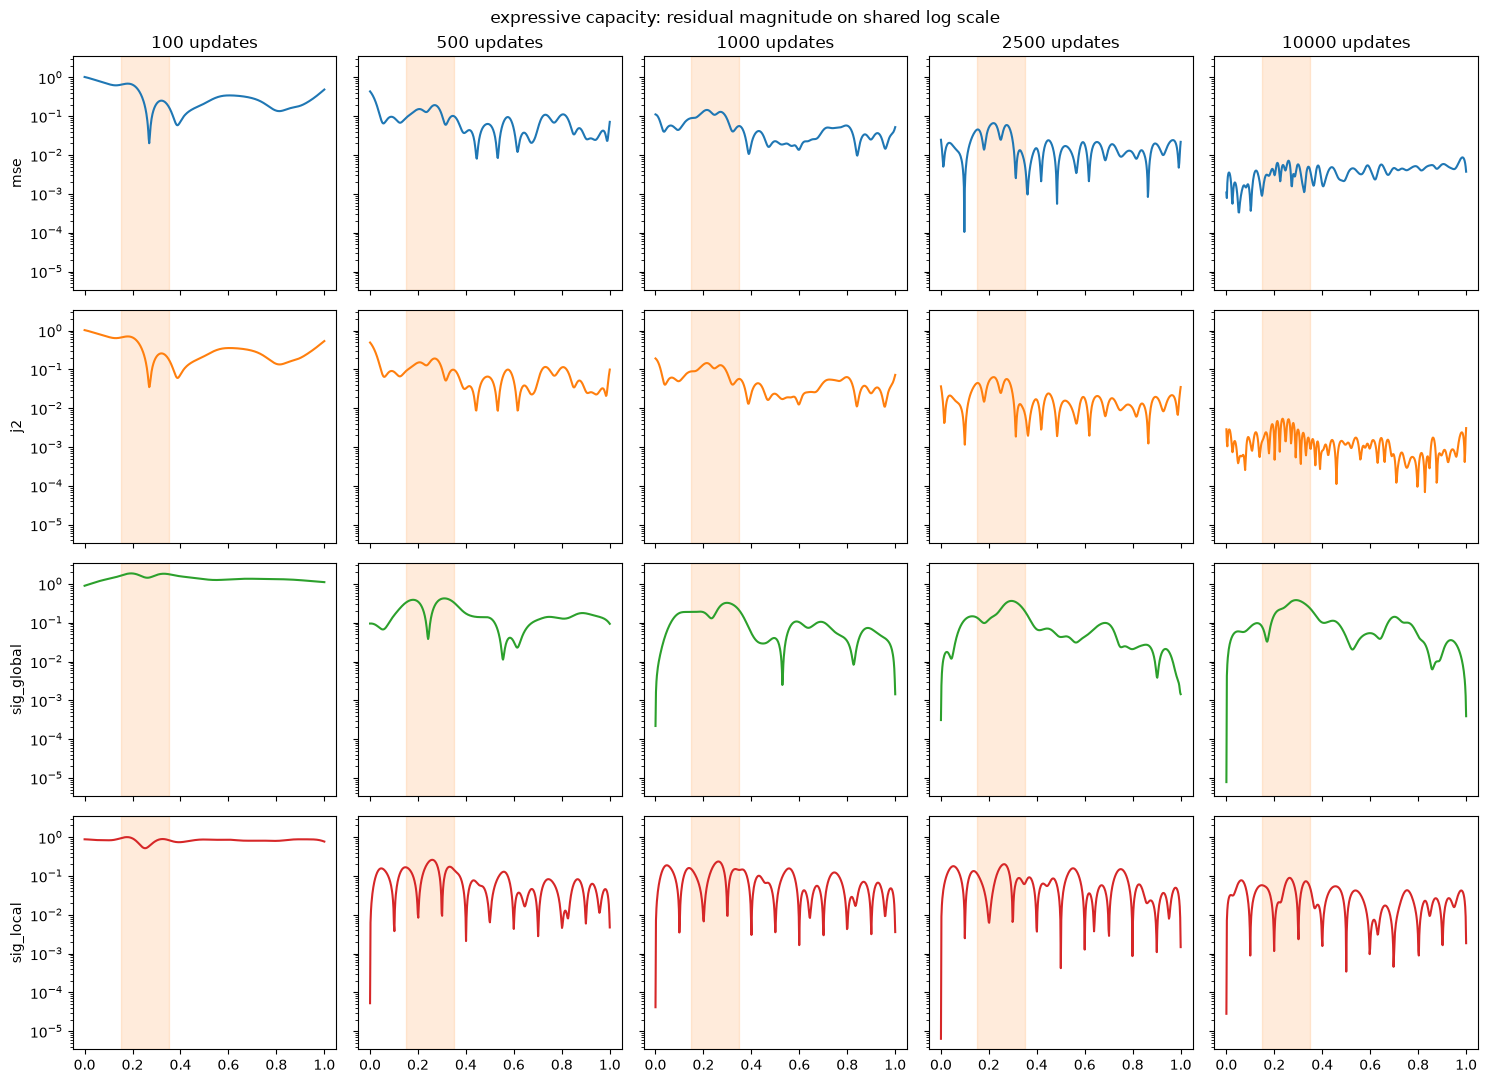

In [13]:
display_updates = [100, 500, 1000, 2500, 10000]
for capacity in ['restricted', 'expressive']:
    path_figure, path_axes = plt.subplots(
        len(loss_order), len(display_updates), figsize=(15, 11),
        sharex=True, sharey=True,
    )
    residual_figure, residual_axes = plt.subplots(
        len(loss_order), len(display_updates), figsize=(15, 11),
        sharex=True, sharey=True,
    )
    for row_index, loss in enumerate(loss_order):
        arrays = np.load(
            PILOT_ROOT / capacity / 'seed0' / 'uniform' / loss
            / 'checkpoint_paths.npz'
        )
        for column_index, update in enumerate(display_updates):
            prediction = arrays[f'prediction_updates_{update:05d}']
            path_axis = path_axes[row_index, column_index]
            path_axis.plot(
                arrays['target'][:, 0], arrays['target'][:, 1],
                color='black', linewidth=1.2,
            )
            path_axis.plot(
                prediction[:, 0], prediction[:, 1],
                color=colors[loss], linewidth=1.2,
            )
            path_axis.set_aspect('equal')
            residual = np.linalg.norm(prediction - arrays['target'], axis=-1)
            residual_axis = residual_axes[row_index, column_index]
            residual_axis.plot(arrays['time'], residual, color=colors[loss])
            residual_axis.axvspan(0.15, 0.35, color='tab:orange', alpha=0.15)
            residual_axis.set_yscale('log')
            if row_index == 0:
                path_axis.set_title(f'{update} updates')
                residual_axis.set_title(f'{update} updates')
        path_axes[row_index, 0].set_ylabel(loss)
        residual_axes[row_index, 0].set_ylabel(loss)
    path_figure.suptitle(f'{capacity} capacity: target and fitted path')
    residual_figure.suptitle(
        f'{capacity} capacity: residual magnitude on shared log scale'
    )
    path_figure.tight_layout()
    residual_figure.tight_layout()


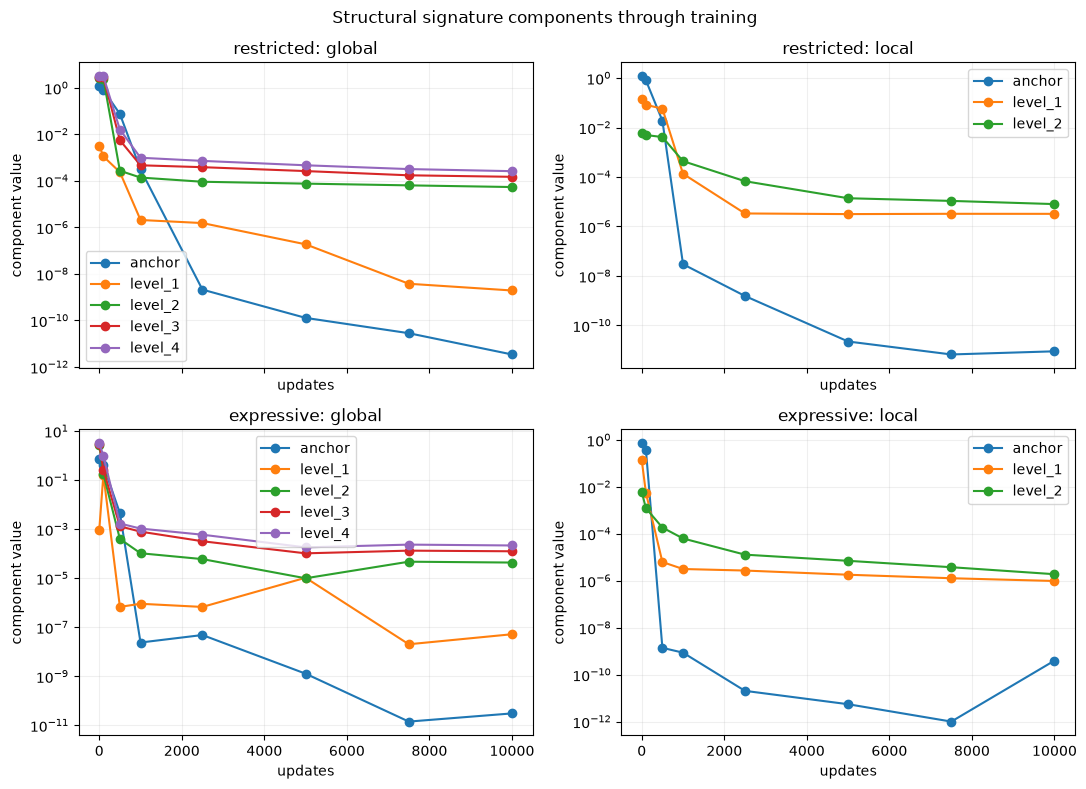

In [14]:
figure, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)
for row_index, capacity in enumerate(['restricted', 'expressive']):
    for column_index, (representation, loss) in enumerate([
        ('global', 'sig_global'), ('local', 'sig_local'),
    ]):
        axis = axes[row_index, column_index]
        rows = level_dynamics[
            (level_dynamics['capacity'] == capacity)
            & (level_dynamics['training loss'] == loss)
            & (level_dynamics['representation'] == representation)
        ]
        for component in rows['component'].unique():
            component_rows = rows[rows['component'] == component]
            axis.plot(
                component_rows['update'],
                component_rows['value'].clip(lower=1e-12),
                marker='o', label=component,
            )
        axis.set_yscale('log')
        axis.set_title(f'{capacity}: {representation}')
        axis.set_xlabel('updates')
        axis.set_ylabel('component value')
        axis.grid(alpha=0.2)
        axis.legend()
figure.suptitle('Structural signature components through training')
figure.tight_layout()


### 12.1 Seed-zero pilot result

Losses learn different features at different rates. Under restricted capacity at update 500, global signature training has lowest dense MSE and global signature discrepancy, while local signature training has lowest event-region error and local signature discrepancy. MSE and $J_2$ overtake both signature fits on pointwise and event-region errors later in training. Early signature advantage is therefore transient and feature-specific rather than a terminal accuracy advantage.

Expressive capacity changes pattern. MSE and $J_2$ already have lower event-region error than both signature losses at update 500. Local signature fit has slightly lower dense MSE at that checkpoint but remains worse in event region. Signature losses rapidly reduce their own discrepancies without consistent improvement in independent pointwise metrics.

Component curves resolve initial audit concern. Anchor dominates early gradients and values, then becomes negligible. Global levels two to four and local levels one to two remain active afterward; observed signature learning is therefore not anchor-only. Global high-level terms continue decreasing while pointwise error stalls, showing that truncated global representation supplies weak control of localized mismatch along trajectory reached by optimizer.

This pilot supports objective recovery plus a restricted-capacity early-learning effect. It does not support a general claim that signature losses recover meaningful path structure faster because it uses one seed and one shared learning rate. That uncertainty motivated the paired-seed closeout and optimizer sensitivity study reported in §§18 and 19.


## 13. Refined quadrature for final path errors

Quadrature changes evaluation of fitted path; it does not change trained parameters. Let

$$
f(t)=\|\widehat Y(t)-Y^\star(t)\|_2^2,\qquad
I=\int_a^b f(t)\,\mathrm dt.
$$

For Experiment A, $Y^\star$ is analytic. Neural ODE uses smooth Fourier time features, tanh vector field and affine decoder, so underlying $\widehat Y$ and squared residual $f$ are smooth. Squaring is relevant: $\|\widehat Y-Y^\star\|_2$ may fail to be differentiable where residual vanishes, while squared norm remains smooth. High-order quadrature expansions therefore apply, subject to separately controlled ODE-solver error.

### 13.1 Trapezoid expansion

On uniform grid $x_i=a+ih$, $i=0,\ldots,n$, define composite trapezoid estimate

$$
T(h)=h\left[\frac{f(a)+f(b)}{2}+\sum_{i=1}^{n-1}f(x_i)\right].
$$

Euler--Maclaurin expansion gives

$$
T(h)=I+\sum_{q=1}^{p-1}
\frac{B_{2q}}{(2q)!}h^{2q}
\left[f^{(2q-1)}(b)-f^{(2q-1)}(a)\right]
+O(h^{2p}),
$$

where $B_{2q}$ are Bernoulli numbers. First terms are

$$
T(h)=I+c_2h^2+c_4h^4+O(h^6),
$$

with

$$
c_2=\frac{f'(b)-f'(a)}{12},\qquad
c_4=-\frac{f^{(3)}(b)-f^{(3)}(a)}{720}.
$$

Dominant trapezoid error is therefore quadratic in grid width.

### 13.2 Simpson as first extrapolation

Halving grid width gives

$$
T(h/2)=I+\frac{c_2h^2}{4}+\frac{c_4h^4}{16}+O(h^6).
$$

Multiply refined estimate by four and subtract coarse estimate:

$$
S(h)=\frac{4T(h/2)-T(h)}{3}
=I-\frac{c_4h^4}{4}+O(h^6).
$$

$c_2h^2$ cancels exactly, leaving fourth-order error. This extrapolated estimate is composite Simpson rule on refined grid. If its fine subinterval width is $\delta=h/2$ and $f\in C^4([a,b])$, standard bound is

$$
|I-S(h)|\leq\frac{b-a}{180}\,\delta^4
\max_{t\in[a,b]}|f^{(4)}(t)|.
$$

For nonuniform original intervals $[t_i,t_{i+1}]$ of width $\Delta_i$, same local midpoint construction remains valid:

$$
S_i=\frac{\Delta_i}{6}
\left[f(t_i)+4f\left(\frac{t_i+t_{i+1}}{2}\right)+f(t_{i+1})\right].
$$

Its local remainder is

$$
\int_{t_i}^{t_{i+1}}f(t)\,\mathrm dt-S_i
=-\frac{\Delta_i^5}{2880}f^{(4)}(\xi_i)
$$

for some $\xi_i\in(t_i,t_{i+1})$. Thus interval widths may vary, provided added point is local midpoint. Ordinary Simpson weights do not apply to arbitrary unequal interior nodes.

### 13.3 Romberg extrapolation

Romberg begins from nested trapezoid grids. Set

$$
R_{k,0}=T(h/2^k).
$$

Recursive extrapolation is

$$
R_{k,j}=R_{k,j-1}
+\frac{R_{k,j-1}-R_{k-1,j-1}}{4^j-1},
\qquad j=1,\ldots,k.
$$

At $j=1$,

$$
R_{k,1}=\frac{4T(h/2^k)-T(h/2^{k-1})}{3},
$$

which is exactly Simpson extrapolation on those two nested grids. Next column removes fourth-order term, following column removes sixth-order term, and induction gives

$$
R_{k,j}=I+O\left((h/2^k)^{2j+2}\right).
$$

Simpson and Romberg are therefore expected to be close on a sufficiently fine grid: they share cancellation of dominant $O(h^2)$ error, and deeper Romberg columns modify only remaining $O(h^4)$ and higher terms. Standard global Romberg uses one nested uniform grid. Adaptive Romberg instead bisects selected panels and builds a local nested dyadic table on each panel; its combined node set may be nonuniform. Arbitrary unrelated nodes do not support the standard Romberg tableau.

### 13.4 Adopted evaluation

Final Experiment A integral metrics use 1,025 uniform points and composite Simpson rule. Since $1,025=2^{10}+1$, same samples also support Romberg validation. Adjacent evaluation times differ by $1/1024$, so saved models are evaluated with RK4 maximum steps $1/1024$, $1/2048$ and $1/4096$: one, two and four substeps per evaluation interval. Agreement between Simpson and Romberg checks quadrature error; successive solver refinements check ODE-solver error. Adaptive Romberg remains deferred: it would estimate quadrature error for one fixed numerically generated path but not Neural ODE solver error, and every newly requested time needs dense output, interpolation or another sequential solve.

For one saved fit, run:

```bash
python scripts/evaluate_fixed_path_resolution.py --run PATH_TO_RUN
```

Next cell collects completed resolution reports.


In [15]:
resolution_rows = []
for run_dir in metrics.get('run_dir', []):
    path = run_dir / 'resolution.json'
    if not path.exists():
        continue
    report = json.loads(path.read_text())
    cfg = report['fit_config']
    for metric, values in report['resolution'].items():
        resolution_rows.append({
            'capacity': run_dir.parts[-4],
            'seed': cfg['seed'],
            'condition': cfg['condition'],
            'loss': cfg['loss'],
            'metric': metric,
            'refined value': report['estimates'][-1][f'{metric}_simpson'],
            **values,
        })
if resolution_rows:
    resolution = pd.DataFrame(resolution_rows)
    display(resolution.set_index(['capacity', 'seed', 'condition', 'loss', 'metric']))
    pair_rows = []
    for keys, group in resolution.groupby(['capacity', 'seed', 'condition', 'metric']):
        indexed = group.set_index('loss')
        if not {'mse', 'j2'}.issubset(indexed.index):
            continue
        comparison = numerical_resolution(
            indexed.loc['mse', 'refined value'],
            indexed.loc['j2', 'refined value'],
            indexed.loc['mse', 'numerical_error_estimate'],
            indexed.loc['j2', 'numerical_error_estimate'],
        )
        pair_rows.append(dict(zip(
            ['capacity', 'seed', 'condition', 'metric'], keys
        )) | comparison)
    if pair_rows:
        display(pd.DataFrame(pair_rows).set_index(
            ['capacity', 'seed', 'condition', 'metric']
        ))
else:
    display(Markdown('Resolution reports are absent.'))


refined value  \
capacity   seed condition loss       metric                  
expressive 0    clustered j2         j2           0.000056   
                                     h1           0.007078   
                          mse        j2           0.000115   
                                     h1           0.012409   
                uniform   h1         j2           0.000003   
...                                                    ...   
restricted 2    uniform   mse        h1           0.005100   
                          sig_global j2           0.018084   
                                     h1           0.354949   
                          sig_local  j2           0.002416   
                                     h1           0.106042   

                                             quadrature_difference  \
capacity   seed condition loss       metric                          
expressive 0    clustered j2         j2               1.970511e-11   
                                     h1               1.125146e-09   
                          mse        j2               2.106263e-11   
                                     h1               8.089363e-09   
                uniform   h1         j2               3.598045e-14   
...                                                            ...   
restricted 2    uniform   mse        h1               2.141817e-09   
                          sig_global j2               2.811616e-12   
                                     h1               6.975476e-12   
                          sig_local  j2               1.064662e-10   
                                     h1               4.959207e-08   

                                             coarse_solver_change  \
capacity   seed condition loss       metric                         
expressive 0    clustered j2         j2              1.946855e-12   
                                     h1              4.386215e-12   
                          mse        j2              3.510374e-12   
                                     h1              6.396741e-13   
                uniform   h1         j2              1.320196e-12   
...                                                           ...   
restricted 2    uniform   mse        h1              4.208791e-12   
                          sig_global j2              1.151558e-12   
                                     h1              1.599942e-12   
                          sig_local  j2              1.394252e-11   
                                     h1              7.708695e-12   

                                             fine_solver_change  \
capacity   seed condition loss       metric                       
expressive 0    clustered j2         j2            1.223116e-13   
                                     h1            2.719491e-13   
                          mse        j2            2.192366e-13   
                                     h1            3.382017e-14   
                uniform   h1         j2            8.235040e-14   
...                                                         ...   
restricted 2    uniform   mse        h1            2.726239e-13   
                          sig_global j2            7.188347e-14   
                                     h1            9.953149e-14   
                          sig_local  j2            8.718334e-13   
                                     h1            4.836131e-13   

                                             rk4_change_ratio  \
capacity   seed condition loss       metric                     
expressive 0    clustered j2         j2             15.917183   
                                     h1             16.128808   
                          mse        j2             16.011811   
                                     h1             18.913982   
                uniform   h1         j2             16.031452   
...                                                       ...   
restricted 2    uniform   mse        

difference  combined_numerical_error  \
capacity   seed condition metric                                         
expressive 0    clustered h1        0.005331              9.214530e-09   
                          j2        0.000059              4.079052e-11   
                uniform   h1        0.000099              2.752909e-10   
                          j2        0.000014              8.969867e-12   
           1    clustered h1        0.003881              7.657665e-09   
                          j2        0.000055              5.299499e-11   
                uniform   h1        0.000086              2.907328e-10   
                          j2        0.000082              1.722478e-11   
           2    clustered h1        0.002826              9.554628e-09   
                          j2        0.000060              4.059117e-11   
                uniform   h1        0.000048              5.699497e-10   
                          j2        0.000034              1.474770e-11   
restricted 0    clustered h1        0.003756              2.764686e-08   
                          j2        0.000472              1.354831e-10   
                uniform   h1        0.000162              1.725513e-09   
                          j2        0.000035              5.419743e-11   
           1    clustered h1        0.031675              9.961833e-08   
                          j2        0.000682              4.496634e-11   
                uniform   h1        0.000925              6.617512e-09   
                          j2        0.000005              1.760382e-11   
           2    clustered h1        0.010779              2.444676e-08   
                          j2        0.000294              1.543839e-10   
                uniform   h1        0.000658              1.126375e-08   
                          j2        0.000004              4.248225e-11   

                                  resolution_margin  resolved  
capacity   seed condition metric                               
expressive 0    clustered h1               0.005331      True  
                          j2               0.000059      True  
                uniform   h1               0.000099      True  
                          j2               0.000014      True  
           1    clustered h1               0.003881      True  
                          j2               0.000055      True  
                uniform   h1               0.000086      True  
                          j2               0.000082      True  
           2    clustered h1               0.002826      True  
                          j2               0.000060      True  
                uniform   h1               0.000048      True  
                          j2               0.000034      True  
restricted 0    clustered h1               0.003756      True  
                          j2               0.000472      True  
                uniform   h1               0.000162      True  
                          j2               0.000035      True  
           1    clustered h1               0.031675      True  
                          j2               0.000682      True  
                uniform   h1               0.000925      True  
                          j2               0.000005      True  
           2    clustered h1               0.010779      True  
                          j2               0.000294      True  
                uniform   h1               0.000658      True  
                          j2               0.000004      True

## 14. Completed three-seed closeout

The final matrix contains 42 exact runs: MSE and $J_2$ under uniform and clustered observations, plus $H^1$, global signature and local signature under uniform observations, for two capacities and three paired seeds. The ten already completed pilot and budget runs are reused by exact identity; 32 new runs complete the matrix. A separate root contains eight seed-zero uniform runs at Adam learning rate $0.003$. Two reused clustered seed-zero budget fits predate checkpoint-path saving, so the final clustered comparison contains all three seeds but any clustered learning-dynamics analysis has fewer complete path histories.

All paired initialization fingerprints agree. Every conclusion below concerns performance after the same 10,000-update compute horizon. Late-window ratios show many objectives are still changing, so final values are not estimates of converged loss minimizers. Three seeds test whether a pattern repeats in this experiment; they do not support a population-level robustness claim.


In [16]:
final_metric_columns = [
    'mse', 'j2', 'h1', 'linf', 'local_j2', 'sig_global', 'sig_local',
]
summary_rows = []
for keys, group in metrics.groupby(['capacity', 'condition', 'loss']):
    row = dict(zip(['capacity', 'condition', 'loss'], keys))
    for metric in final_metric_columns:
        values = group[metric].dropna()
        row[metric] = (
            f'{values.mean():.3g} ± {values.std(ddof=1):.2g}'
            if len(values) > 1 else f'{values.iloc[0]:.3g}'
        )
    summary_rows.append(row)
final_summary = pd.DataFrame(summary_rows).sort_values(
    ['capacity', 'condition', 'loss'], ignore_index=True,
)
display(final_summary.set_index(['capacity', 'condition', 'loss']))

late_rows = []
for _, row in metrics.iterrows():
    values = [
        item['train_loss']
        for item in json.loads((row['run_dir'] / 'history.json').read_text())
    ]
    late_rows.append({
        'capacity': row['capacity'], 'seed': row['seed'],
        'condition': row['condition'], 'loss': row['loss'],
        'late R': statistics.median(values[9500:10000])
            / statistics.median(values[9000:9500]),
    })
late_ratios = pd.DataFrame(late_rows)
display(pd.Series({
    'runs with R < 0.95': int((late_ratios['late R'] < 0.95).sum()),
    'runs in matrix': len(late_ratios),
    'minimum R': late_ratios['late R'].min(),
    'maximum R': late_ratios['late R'].max(),
}, name='finite-budget diagnostic'))


mse                  j2  \
capacity   condition loss                                                 
expressive clustered j2           8.4e-05 ± 3.2e-05  8.41e-05 ± 3.2e-05   
                     mse         0.000142 ± 3.3e-05  0.000142 ± 3.3e-05   
           uniform   h1          2.57e-05 ± 4.2e-05  2.57e-05 ± 4.2e-05   
                     j2            3.07e-05 ± 5e-05  3.06e-05 ± 4.9e-05   
                     mse         1.95e-05 ± 1.5e-05  1.95e-05 ± 1.5e-05   
                     sig_global    0.0186 ± 0.00051    0.0186 ± 0.00051   
                     sig_local    0.00148 ± 0.00016   0.00148 ± 0.00016   
restricted clustered j2          0.000222 ± 9.9e-05  0.000223 ± 9.9e-05   
                     mse         0.000704 ± 0.00018  0.000705 ± 0.00018   
           uniform   h1            7.11e-07 ± 8e-07    7.11e-07 ± 8e-07   
                     j2          3.19e-05 ± 1.3e-05  3.18e-05 ± 1.3e-05   
                     mse         2.03e-05 ± 8.2e-06  2.03e-05 ± 8.2e-06   
                     sig_global     0.0196 ± 0.0015     0.0196 ± 0.0015   
                     sig_local     0.00383 ± 0.0014    0.00384 ± 0.0014   

                                                 h1              linf  \
capacity   condition loss                                               
expressive clustered j2               0.01 ± 0.0031   0.0358 ± 0.0051   
                     mse             0.014 ± 0.0019   0.0431 ± 0.0014   
           uniform   h1          4.64e-05 ± 5.3e-05  0.00501 ± 0.0058   
                     j2           0.00069 ± 0.00014  0.00974 ± 0.0085   
                     mse         0.000711 ± 0.00021   0.0073 ± 0.0025   
                     sig_global      0.359 ± 0.0022      0.38 ± 0.002   
                     sig_local      0.0568 ± 0.0074   0.0931 ± 0.0092   
restricted clustered j2               0.0263 ± 0.01    0.0576 ± 0.018   
                     mse            0.0417 ± 0.0058    0.0842 ± 0.013   
           uniform   h1          0.000114 ± 5.1e-05  0.00283 ± 0.0013   
                     j2            0.00453 ± 0.0015   0.0147 ± 0.0018   
                     mse           0.00467 ± 0.0015    0.0146 ± 0.005   
                     sig_global       0.396 ± 0.056     0.379 ± 0.032   
                     sig_local         0.134 ± 0.03     0.161 ± 0.029   

                                           local_j2          sig_global  \
capacity   condition loss                                                 
expressive clustered j2          0.000281 ± 7.5e-05  0.000627 ± 0.00021   
                     mse         0.000426 ± 0.00014  0.000581 ± 2.1e-05   
           uniform   h1          1.88e-05 ± 3.1e-05  0.000235 ± 0.00038   
                     j2          9.97e-06 ± 6.7e-06   0.000909 ± 0.0015   
                     mse         1.34e-05 ± 7.9e-06  0.000126 ± 3.9e-05   
                     sig_global     0.0722 ± 0.0044  0.000429 ± 3.8e-05   
                     sig_local     0.0028 ± 0.00024  6.93e-05 ± 8.7e-06   
restricted clustered j2          0.000564 ± 0.00018    0.00166 ± 0.0012   
                     mse           0.0025 ± 0.00069    0.00765 ± 0.0034   
           uniform   h1           1.5e-06 ± 9.5e-07   4.8e-06 ± 4.9e-06   
                     j2          4.76e-05 ± 2.1e-05  0.000332 ± 0.00012   
                     mse         5.31e-05 ± 3.1e-05  8.68e-05 ± 6.1e-05   
                     sig_global     0.0747 ± 0.0051  0.000433 ± 2.8e-05   
                     sig_local     0.00843 ± 0.0034  0.000189 ± 7.8e-05   

                                          sig_local  
capacity   condition loss                            
expressive clustered j2          4.54e-05 ± 1.3e-05  
                     mse           6.61e-05 ± 5e-05  
           uniform   h1            1.46e-06 ± 2e-06  
                     j2          6.63e-06 ± 1.7e-06  
                     mse         3.05e-06 ± 5.5e-07  
                     sig_global     0.0212 ± 0.0013  
                     sig_local   3.45e-06 ± 5

runs with R < 0.95    33.000000
runs in matrix        42.000000
minimum R              0.481159
maximum R              1.138412
Name: finite-budget diagnostic, dtype: float64

## 15. MSE versus $J_2$: effect of observation density

This is the controlled integral-norm comparison. MSE and $J_2$ use the same squared residual and differ only in the measure placed on time. Positive differences below mean that the $J_2$-trained model has lower dense error than its paired MSE-trained model. Absolute differences are reported because percentage changes become unstable once both errors are very small.


MSE-trained dense MSE  J2-trained dense MSE  \
capacity   seed condition                                                
expressive 0    clustered               0.000115              0.000056   
                uniform                 0.000017              0.000003   
           1    clustered               0.000132              0.000077   
                uniform                 0.000006              0.000088   
           2    clustered               0.000179              0.000119   
                uniform                 0.000036              0.000002   
restricted 0    clustered               0.000798              0.000327   
                uniform                 0.000012              0.000047   
           1    clustered               0.000812              0.000132   
                uniform                 0.000028              0.000024   
           2    clustered               0.000501              0.000208   
                uniform                 0.000021              0.000025   

                           dense MSE advantage  H1 advantage  \
capacity   seed condition                                      
expressive 0    clustered             0.000059      0.005331   
                uniform               0.000014      0.000099   
           1    clustered             0.000055      0.003882   
                uniform              -0.000082     -0.000085   
           2    clustered             0.000060      0.002826   
                uniform               0.000034      0.000048   
restricted 0    clustered             0.000471      0.003723   
                uniform              -0.000035      0.000169   
           1    clustered             0.000681      0.031674   
                uniform               0.000004      0.000924   
           2    clustered             0.000293      0.010758   
                uniform              -0.000004     -0.000659   

                           supremum advantage  event advantage  \
capacity   seed condition                                        
expressive 0    clustered            0.012040         0.000234   
                uniform              0.003313         0.000009   
           1    clustered            0.009526        -0.000003   
                uniform             -0.015101        -0.000013   
           2    clustered            0.000166         0.000202   
                uniform              0.004478         0.000014   
restricted 0    clustered            0.022436         0.002388   
                uniform             -0.003972        -0.000007   
           1    clustered            0.045327         0.002117   
                uniform              0.004615         0.000032   
           2    clustered            0.011790         0.001306   
                uniform             -0.000795        -0.000008   

                           path RMS separation  
capacity   seed condition                       
expressive 0    clustered             0.005507  
                uniform               0.003717  
           1    clustered             0.006445  
                uniform               0.007568  
           2    clustered             0.009445  
                uniform               0.005867  
restricted 0    clustered             0.025091  
                uniform               0.006875  
           1    clustered             0.024088  
                uniform               0.003331  
           2    clustered             0.017242  
                uniform               0.002826

MSE-trained mean  J2-trained mean  \
capacity   condition                                      
expressive clustered          0.000142         0.000084   
           uniform            0.000019         0.000031   
restricted clustered          0.000704         0.000222   
           uniform            0.000020         0.000032   

                      relative reduction (ratio of means)  J2 lower dense MSE  \
capacity   condition                                                            
expressive clustered                             0.408103                   3   
           uniform                              -0.574740                   2   
restricted clustered                             0.684136                   3   
           uniform                              -0.569755                   1   

                      paired seeds  mean path RMS separation  
capacity   condition                                          
expressive clustered             3                  0.007133  
           uniform               3                  0.005717  
restricted clustered             3                  0.022140  
           uniform               3                  0.004344

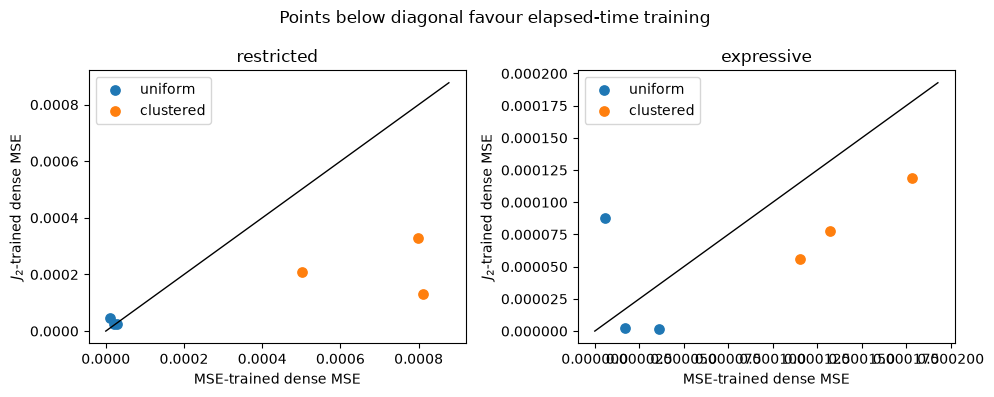

In [17]:
sampling_rows = []
pointwise_rows = metrics[metrics['loss'].isin(['mse', 'j2'])]
for keys, group in pointwise_rows.groupby(['capacity', 'seed', 'condition']):
    paired = group.set_index('loss')
    mse_path = np.load(paired.loc['mse', 'run_dir'] / 'paths.npz')['prediction']
    j2_path = np.load(paired.loc['j2', 'run_dir'] / 'paths.npz')['prediction']
    sampling_rows.append({
        **dict(zip(['capacity', 'seed', 'condition'], keys)),
        'MSE-trained dense MSE': paired.loc['mse', 'mse'],
        'J2-trained dense MSE': paired.loc['j2', 'mse'],
        'dense MSE advantage': paired.loc['mse', 'mse'] - paired.loc['j2', 'mse'],
        'H1 advantage': paired.loc['mse', 'h1'] - paired.loc['j2', 'h1'],
        'supremum advantage': paired.loc['mse', 'linf'] - paired.loc['j2', 'linf'],
        'event advantage': paired.loc['mse', 'local_j2'] - paired.loc['j2', 'local_j2'],
        'path RMS separation': float(np.sqrt(np.mean(np.sum(
            (mse_path - j2_path) ** 2, axis=-1,
        )))),
    })
sampling_pairs = pd.DataFrame(sampling_rows)
display(sampling_pairs.set_index(['capacity', 'seed', 'condition']))

sampling_group_rows = []
for keys, group in sampling_pairs.groupby(['capacity', 'condition']):
    mse_mean = group['MSE-trained dense MSE'].mean()
    j2_mean = group['J2-trained dense MSE'].mean()
    sampling_group_rows.append({
        **dict(zip(['capacity', 'condition'], keys)),
        'MSE-trained mean': mse_mean,
        'J2-trained mean': j2_mean,
        'relative reduction (ratio of means)': (mse_mean - j2_mean) / mse_mean,
        'J2 lower dense MSE': int((group['dense MSE advantage'] > 0).sum()),
        'paired seeds': len(group),
        'mean path RMS separation': group['path RMS separation'].mean(),
    })
sampling_group_summary = pd.DataFrame(sampling_group_rows)
display(sampling_group_summary.set_index(['capacity', 'condition']))

figure, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
for axis, capacity in zip(axes, ['restricted', 'expressive']):
    subset = sampling_pairs[sampling_pairs['capacity'] == capacity]
    for condition, color in [('uniform', 'tab:blue'), ('clustered', 'tab:orange')]:
        group = subset[subset['condition'] == condition]
        axis.scatter(
            group['MSE-trained dense MSE'], group['J2-trained dense MSE'],
            label=condition, color=color, s=45,
        )
    limit = 1.08 * subset[[
        'MSE-trained dense MSE', 'J2-trained dense MSE',
    ]].to_numpy().max()
    axis.plot([0, limit], [0, limit], color='black', linewidth=1)
    axis.set_xlabel('MSE-trained dense MSE')
    axis.set_ylabel('$J_2$-trained dense MSE')
    axis.set_title(capacity)
    axis.legend()
figure.suptitle('Points below diagonal favour elapsed-time training')
figure.tight_layout()


### 15.1 Result

Under clustered sampling, $J_2$ gives lower final dense MSE than MSE in every paired run. It also improves dense $H^1$ and supremum error in every pair and event-region error in all but one. Adjacent table computes both ratio-of-means and mean-of-paired-ratios summaries; both show a substantial reduction, with a larger effect under restricted capacity.

Under uniform sampling, neither objective has a consistent dense-MSE advantage, and both attain small absolute errors. Fitted-path separation is much larger under clustering for restricted capacity and only modestly larger for expressive capacity. Thus the intended density manipulation matters most when approximation capacity is constrained.

This supports the mechanism already derived in Notebook 01: sample MSE follows the observation distribution, whereas $J_2$ approximates elapsed-time error. Dense MSE on the fixed uniform evaluation grid is itself an elapsed-time approximation, so its direction of preference under clustering is not an independent surprise: $J_2$ trains toward the evaluation measure while sample MSE does not. The experiment tests whether known measure mismatch survives finite capacity and finite optimization, and how large the learned-path effect becomes. Evidence combines a uniform-grid null control, a consistent clustered effect and substantial magnitude, with evaluation grid fixed before results. It does not establish different converged optima because many late ratios remain below descriptive stopping threshold. Preceding cell calculates every count and ratio from completed-run registry assembled in §8.2; exact source directories are listed in §23.


## 16. $H^1$ as the derivative-supervision control

$H^1$ tests an alternative explanation for local-structure recovery: direct tangent information may be more useful than signature geometry on this smooth analytic target. It receives the exact target derivative, so it is deliberately a richer supervision condition rather than an equal-information competitor.


In [18]:
h1_rows = []
uniform_metrics = metrics[metrics['condition'] == 'uniform']
for keys, group in uniform_metrics.groupby(['capacity', 'seed']):
    indexed = group.set_index('loss')
    pointwise = indexed.loc[['mse', 'j2']]
    h1_rows.append({
        **dict(zip(['capacity', 'seed'], keys)),
        **{
            f'{metric} ratio to best pointwise':
                indexed.loc['h1', metric] / pointwise[metric].min()
            for metric in ['mse', 'h1', 'linf', 'local_j2', 'sig_global', 'sig_local']
        },
    })
h1_comparison = pd.DataFrame(h1_rows)
display(h1_comparison.set_index(['capacity', 'seed']))
display(pd.Series({
    'lower final dense MSE than both pointwise fits': int((
        h1_comparison['mse ratio to best pointwise'] < 1
    ).sum()),
    'lower final H1 than both pointwise fits': int((
        h1_comparison['h1 ratio to best pointwise'] < 1
    ).sum()),
    'paired capacity-seed groups': len(h1_comparison),
}, name='$H^1$ final comparison'))


mse ratio to best pointwise  h1 ratio to best pointwise  \
capacity   seed                                                            
expressive 0                        0.981173                    0.019213   
           1                       13.202928                    0.191126   
           2                        0.022481                    0.026773   
restricted 0                        0.015674                    0.020532   
           1                        0.068362                    0.032031   
           2                        0.015209                    0.024380   

                 linf ratio to best pointwise  \
capacity   seed                                 
expressive 0                         0.420909   
           1                         2.637720   
           2                         0.252531   
restricted 0                         0.175550   
           1                         0.299561   
           2                         0.164919   

                 local_j2 ratio to best pointwise  \
capacity   seed                                     
expressive 0                             0.249643   
           1                            12.570741   
           2                             0.013758   
restricted 0                             0.036330   
           1                             0.051901   
           2                             0.021227   

                 sig_global ratio to best pointwise  \
capacity   seed                                       
expressive 0                               0.634871   
           1                               4.083586   
           2                               0.017565   
restricted 0                               0.068878   
           1                               0.073019   
           2                               0.026566   

                 sig_local ratio to best pointwise  
capacity   seed                                     
expressive 0                              0.116085  
           1                              1.490481  
           2                              0.062157  
restricted 0                              0.020403  
           1                              0.027165  
           2                              0.032269

lower final dense MSE than both pointwise fits    5
lower final H1 than both pointwise fits           6
paired capacity-seed groups                       6
Name: $H^1$ final comparison, dtype: int64

### 16.1 Result

$H^1$ has lower final derivative-sensitive error than both pointwise fits in every capacity-seed group and lower dense MSE, supremum error and event error in all but one. At the early checkpoint shown in preceding table, it has the lowest value of all compared losses on every general error metric in every group. One expressive seed later moves away from its best pointwise fit, another warning that terminal update is not convergence.

Derivative supervision is therefore the most effective way tested here to reconstruct this particular smooth path quickly. It also shows that recovery of the oscillatory event is not unique evidence for signatures. This does not make $H^1$ a general replacement: its advantage uses derivatives unavailable in ordinary sampled data. Moreover, if $x\in H^1([0,T])$, then $x$ is absolutely continuous and $\operatorname{TV}(x)\leq\sqrt{T}\,\|\dot x\|_{L^2}<\infty$, whereas Brownian paths are almost surely neither absolutely continuous nor of bounded variation. The adjacent cell calculates all six paired comparisons from stored final metrics in the completed-run registry of §8.2.


## 17. Signature-loss closeout

A signature-trained model should first be checked on its own signature discrepancy. If a pointwise-trained model reaches a lower value of that same objective from the paired initialization, the signature-trained endpoint is an optimization failure and cannot be interpreted as the path preferred by signature geometry. The second check asks whether a smaller signature discrepancy also implies a recognizable improvement in pointwise or event error.


In [19]:
signature_rows = []
for keys, group in uniform_metrics.groupby(['capacity', 'seed']):
    indexed = group.set_index('loss')
    pointwise = indexed.loc[['mse', 'j2']]
    for signature_loss in ['sig_global', 'sig_local']:
        signature_rows.append({
            **dict(zip(['capacity', 'seed'], keys)),
            'signature loss': signature_loss,
            'own discrepancy ratio': indexed.loc[signature_loss, signature_loss]
                / pointwise[signature_loss].min(),
            'dense MSE ratio': indexed.loc[signature_loss, 'mse']
                / pointwise['mse'].min(),
            'event error ratio': indexed.loc[signature_loss, 'local_j2']
                / pointwise['local_j2'].min(),
        })
signature_comparison = pd.DataFrame(signature_rows)
display(signature_comparison.set_index([
    'capacity', 'seed', 'signature loss',
]))
display(signature_comparison.groupby(
    ['capacity', 'signature loss']
)[['own discrepancy ratio', 'dense MSE ratio', 'event error ratio']].agg(
    ['mean', 'min', 'max']
))
local_final = signature_comparison[
    signature_comparison['signature loss'] == 'sig_local'
].copy()
local_final['beats both pointwise fits'] = local_final['own discrepancy ratio'] < 1
local_capacity_counts = local_final.groupby('capacity').agg(
    wins=('beats both pointwise fits', 'sum'),
    groups=('beats both pointwise fits', 'size'),
)
display(local_capacity_counts)
display(pd.Series({
    'local-signature wins': int(local_final['beats both pointwise fits'].sum()),
    'capacity-seed groups': len(local_final),
}, name='final local-signature comparison'))


own discrepancy ratio  dense MSE ratio  \
capacity   seed signature loss                                           
expressive 0    sig_global                   7.597766      7221.549190   
                sig_local                    0.792609       502.040902   
           1    sig_global                   2.768876      3383.916147   
                sig_local                    1.519871       277.671706   
           2    sig_global                   7.679880     11466.440402   
                sig_local                    1.209323       999.533422   
restricted 0    sig_global                  22.402266      1758.399438   
                sig_local                    0.936635       429.541320   
           1    sig_global                   2.910810       822.695582   
                sig_local                    0.325314       165.760676   
           2    sig_global                   4.312652       874.000389   
                sig_local                    0.207537       116.743249   

                                event error ratio  
capacity   seed signature loss                     
expressive 0    sig_global            8786.150743  
                sig_local              336.586448  
           1    sig_global           17909.775683  
                sig_local              711.551265  
           2    sig_global           15424.497398  
                sig_local              588.534301  
restricted 0    sig_global            4192.975230  
                sig_local              442.331671  
           1    sig_global            1526.806902  
                sig_local              242.535445  
           2    sig_global            1171.851738  
                sig_local               84.478668

own discrepancy ratio                       \
                                           mean       min        max   
capacity   signature loss                                              
expressive sig_global                  6.015507  2.768876   7.679880   
           sig_local                   1.173934  0.792609   1.519871   
restricted sig_global                  9.875243  2.910810  22.402266   
           sig_local                   0.489829  0.207537   0.936635   

                          dense MSE ratio                             \
                                     mean          min           max   
capacity   signature loss                                              
expressive sig_global         7357.301913  3383.916147  11466.440402   
           sig_local           593.082010   277.671706    999.533422   
restricted sig_global         1151.698470   822.695582   1758.399438   
           sig_local           237.348415   116.743249    429.541320   

                          event error ratio                             
                                       mean          min           max  
capacity   signature loss                                               
expressive sig_global          14040.141275  8786.150743  17909.775683  
           sig_local             545.557338   336.586448    711.551265  
restricted sig_global           2297.211290  1171.851738   4192.975230  
           sig_local             256.448595    84.478668    442.331671

,wins,groups
capacity,,
expressive,1,3
restricted,3,3


local-signature wins    4
capacity-seed groups    6
Name: final local-signature comparison, dtype: int64

### 17.1 Result

Global-signature training finishes with a larger global-signature discrepancy than the best paired pointwise fit in every group, by the factors displayed in preceding table. This is a clear finite-budget optimization failure: comparison already contains a feasible fitted model with a better value of same global-signature objective. Terminal global fit must not be described as approximation selected by global signature distance.

Local-signature training reaches a lower local-signature discrepancy than both pointwise fits in every restricted group but only one expressive group under main learning rate. Even where local-signature training wins on its own discrepancy, preceding ratios show much larger pointwise and event errors. Local representation can therefore judge a fit structurally closer while substantial pointwise and event mismatch remains. This is evidence that chosen path-space geometry differs from pointwise geometry, but not evidence that it is better for reconstructing this target.

Capacity split is consistent with the prediction that losses sharing same zero-error target separate most clearly when approximation is binding and become harder to distinguish once target is representable. It should be read as a capacity-dependent pattern in a small seed sample rather than a general theorem. Two signature constructions remain separate conclusions: global depth four is dominated by optimization failure here, whereas ten-block local depth two is trainable but weakly controls target between retained features. Preceding cell computes every ratio from stored `metrics.json` files located through completed-run registry; §23 lists all contributing result roots.


## 18. Learning dynamics across paired seeds

Checkpoint analysis distinguishes early feature recovery from terminal accuracy. Curves show the mean across three seeds, with the full seed range shaded. They compare only common evaluation metrics, since raw training losses have different scales.


mse  j2  h1  sig_global  sig_local
update metric                                        
500    mse           0   0   3           2          1
       h1            0   0   5           1          0
       linf          0   0   3           3          0
       local_j2      0   0   5           0          1
       sig_global    0   0   0           6          0
       sig_local     0   0   0           1          5
1000   mse           0   0   6           0          0
       h1            0   0   6           0          0
       linf          0   0   6           0          0
       local_j2      0   0   6           0          0
       sig_global    0   0   3           3          0
       sig_local     0   0   3           0          3
2500   mse           0   0   6           0          0
       h1            0   0   6           0          0
       linf          0   0   6           0          0
       local_j2      0   0   6           0          0
       sig_global    0   0   5           1          0
       sig_local     0   0   5           0          1
5000   mse           0   0   6           0          0
       h1            0   0   6           0          0
       linf          0   0   6           0          0
       local_j2      0   0   6           0          0
       sig_global    0   0   6           0          0
       sig_local     0   0   6           0          0
10000  mse           1   0   5           0          0
       h1            0   0   6           0          0
       linf          1   0   5           0          0
       local_j2      1   0   5           0          0
       sig_global    0   0   5           0          1
       sig_local     1   0   5           0          0

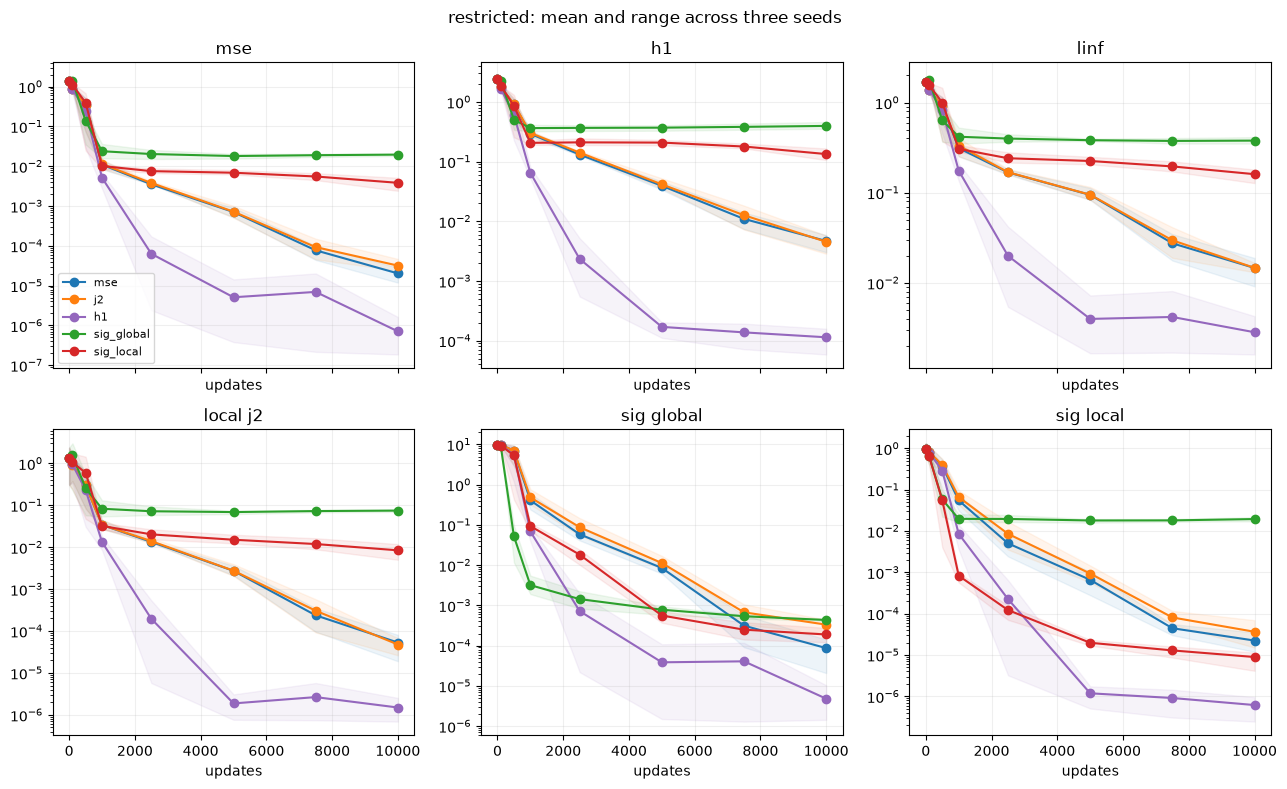

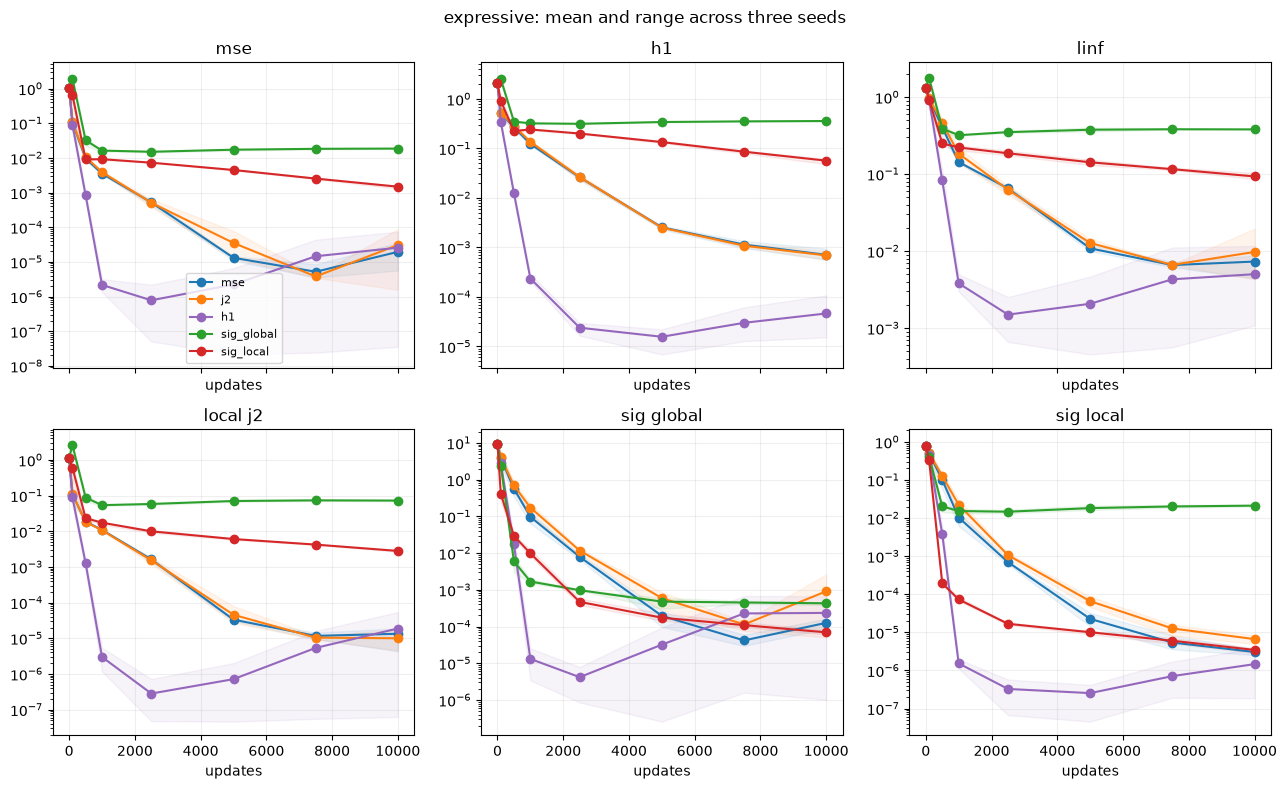

In [20]:
all_checkpoint_rows = []
for _, run_row in uniform_metrics.iterrows():
    checkpoints = json.loads((run_row['run_dir'] / 'checkpoints.json').read_text())
    for checkpoint in checkpoints:
        all_checkpoint_rows.append({
            'capacity': run_row['capacity'], 'seed': run_row['seed'],
            'loss': run_row['loss'],
            'update': checkpoint['updates_completed'],
            **checkpoint['metrics'],
        })
all_dynamics = pd.DataFrame(all_checkpoint_rows)
all_loss_order = ['mse', 'j2', 'h1', 'sig_global', 'sig_local']
all_colors = {
    'mse': 'tab:blue', 'j2': 'tab:orange', 'h1': 'tab:purple',
    'sig_global': 'tab:green', 'sig_local': 'tab:red',
}
for capacity in ['restricted', 'expressive']:
    figure, axes = plt.subplots(2, 3, figsize=(13, 8), sharex=True)
    subset = all_dynamics[all_dynamics['capacity'] == capacity]
    for axis, metric in zip(axes.flat, [
        'mse', 'h1', 'linf', 'local_j2', 'sig_global', 'sig_local',
    ]):
        for loss in all_loss_order:
            grouped = subset[subset['loss'] == loss].groupby('update')[metric]
            mean = grouped.mean().clip(lower=1e-14)
            low = grouped.min().clip(lower=1e-14)
            high = grouped.max().clip(lower=1e-14)
            axis.plot(mean.index, mean, marker='o', color=all_colors[loss], label=loss)
            axis.fill_between(mean.index, low, high, color=all_colors[loss], alpha=0.08)
        axis.set_yscale('log')
        axis.set_title(metric.replace('_', ' '))
        axis.set_xlabel('updates')
        axis.grid(alpha=0.2)
    axes[0, 0].legend(fontsize=8)
    figure.suptitle(f'{capacity}: mean and range across three seeds')
    figure.tight_layout()

winner_rows = []
for update in [500, 1000, 2500, 5000, 10000]:
    subset = all_dynamics[all_dynamics['update'] == update]
    for metric in ['mse', 'h1', 'linf', 'local_j2', 'sig_global', 'sig_local']:
        winners = subset.loc[
            subset.groupby(['capacity', 'seed'])[metric].idxmin(), 'loss'
        ].value_counts()
        winner_rows.append({
            'update': update, 'metric': metric,
            **{loss: int(winners.get(loss, 0)) for loss in all_loss_order},
        })
winner_counts = pd.DataFrame(winner_rows)
display(winner_counts.set_index(['update', 'metric']))


### 18.1 Result

At the first informative checkpoint, global-signature training has the lowest global-signature discrepancy in every capacity-seed group, while local-signature training has the lowest local-signature discrepancy in most groups. The signature objectives therefore produce rapid recovery of their own retained features. At the same checkpoint, however, $H^1$ already has the lowest event error in most groups; signatures do not uniquely recover the oscillatory event. The preceding cell calculates the exact checkpoint counts from the saved histories.

At the next checkpoint, $H^1$ has the lowest pointwise, derivative, supremum and event error in every group. By the terminal checkpoint, global-signature training is no longer best on its own metric in any group, while local-signature training remains best on its own metric in a majority. Early signature objective recovery is real but does not persist as a general accuracy advantage. Exact checkpoints, counts and rankings are displayed by the preceding cell.

The mean curves and wide seed ranges also show non-monotone common metrics. Adam may continue reducing one training objective while another metric worsens, and even the fitted training objective can fluctuate near a narrow valley. The defensible conclusion is about feature-specific finite-budget dynamics, not a universal ranking of losses or converged path geometries. The adjacent analysis reads each run's stored `checkpoints.json`; checkpoint paths and metrics are never inferred from the terminal fit.


## 19. Adam learning-rate sensitivity

Eight seed-zero uniform runs repeat MSE, $J_2$, global signature and local signature at learning rate $0.003$ instead of $0.001$. They live in a separate result root, so they neither overwrite nor enter the three-seed main means. Ratios below compare final common metrics at $0.003$ with the exact paired $0.001$ run; values below one favour the larger learning rate.


In [21]:
lr_rows = []
base_lr = metrics[(metrics['seed'] == 0) & (metrics['condition'] == 'uniform')]
for keys, faster_group in sensitivity_metrics.groupby(['capacity', 'loss']):
    capacity, loss = keys
    faster = faster_group.iloc[0]
    base = base_lr[(base_lr['capacity'] == capacity) & (base_lr['loss'] == loss)].iloc[0]
    lr_rows.append({
        'capacity': capacity, 'loss': loss,
        **{f'{metric} ratio': faster[metric] / base[metric]
           for metric in final_metric_columns},
    })
lr_comparison = pd.DataFrame(lr_rows).sort_values(
    ['capacity', 'loss'], ignore_index=True,
)
display(lr_comparison.set_index(['capacity', 'loss']))

lr_signature_rows = []
for capacity, group in sensitivity_metrics.groupby('capacity'):
    indexed = group.set_index('loss')
    pointwise = indexed.loc[['mse', 'j2']]
    for loss in ['sig_global', 'sig_local']:
        lr_signature_rows.append({
            'capacity': capacity, 'signature loss': loss,
            'own discrepancy ratio to best pointwise':
                indexed.loc[loss, loss] / pointwise[loss].min(),
            'dense MSE ratio to best pointwise':
                indexed.loc[loss, 'mse'] / pointwise['mse'].min(),
        })
display(pd.DataFrame(lr_signature_rows).set_index([
    'capacity', 'signature loss',
]))


mse ratio  j2 ratio  h1 ratio  linf ratio  \
capacity   loss                                                    
expressive j2           1.389616  1.397994  0.435080    1.101494   
           mse          0.056292  0.056222  0.426296    0.378661   
           sig_global   1.044722  1.044722  1.012667    1.011450   
           sig_local    0.237358  0.237358  0.501807    0.510119   
restricted j2           0.119056  0.118800  0.514866    0.480032   
           mse          0.371622  0.371668  0.454067    0.657615   
           sig_global   0.878587  0.878587  0.842781    0.914294   
           sig_local    0.202773  0.202772  0.424782    0.550597   

                       local_j2 ratio  sig_global ratio  sig_local ratio  
capacity   loss                                                           
expressive j2                0.196751          1.372655         0.170815  
           mse               0.082648          0.047835         0.187774  
           sig_global        1.082060          1.027946         1.021461  
           sig_local         0.225921          0.582015         0.532145  
restricted j2                0.291554          0.227203         0.689334  
           mse               0.392209          0.489235         0.161414  
           sig_global        0.891933          0.922071         0.898534  
           sig_local         0.306929          0.312869         0.172147

own discrepancy ratio to best pointwise  \
capacity   signature loss                                            
expressive sig_global                                    65.891067   
           sig_local                                      2.246224   
restricted sig_global                                    42.221942   
           sig_local                                      0.998917   

                           dense MSE ratio to best pointwise  
capacity   signature loss                                     
expressive sig_global                           20341.397066  
           sig_local                              321.286054  
restricted sig_global                            4157.203836  
           sig_local                              234.376313

### 19.1 Result

The larger learning rate accelerates and improves several pointwise and local-signature runs, but not uniformly. Expressive $J_2$ finishes with worse dense MSE despite being better at earlier checkpoints. Global-signature error changes little and its own-objective ranking becomes worse relative to the much improved pointwise fits. Local-signature dense MSE improves, but remains orders of magnitude above the best pointwise fit; its own discrepancy is approximately tied with the best restricted pointwise fit and worse than the best expressive value. The preceding table gives the exact paired ratios.

Thus learning rate materially changes optimization speed and terminal values, but it does not reverse the main signature conclusions. Selecting whichever learning rate gives best result for each loss after seeing outcomes would remove matched-optimizer comparison, so $0.003$ remains a sensitivity arm rather than replacement for main matrix. The adjacent cell compares stored metrics under `../results/runs/neural_ode_fixed_path_lr3e3/` with paired $0.001$ runs from the registry in §8.2.


## 20. Numerical-resolution result

All 42 final models are reevaluated in double precision on 1,025 points. Composite Simpson and full Romberg use the same nested grid. RK4 limits $1/1024$, $1/2048$ and $1/4096$ give one, two and four solver substeps per evaluation interval. The finest two estimates supply a conservative solver-error estimate, with division by 15 when fourth-order convergence is observed.


In [22]:
if resolution_rows:
    numerical_summary = resolution.groupby('metric').agg(
        reports=('loss', 'count'),
        max_simpson_romberg=('quadrature_difference', 'max'),
        max_finest_solver_change=('fine_solver_change', 'max'),
        max_total_error_estimate=('numerical_error_estimate', 'max'),
        fourth_order_cases=('richardson_applicable', 'sum'),
    )
    display(numerical_summary)
    resolved_pairs = pd.DataFrame(pair_rows)
    display(pd.Series({
        'resolved MSE-J2 metric comparisons': int(resolved_pairs['resolved'].sum()),
        'paired metric comparisons': len(resolved_pairs),
        'smallest difference/error ratio': (
            resolved_pairs['difference']
            / resolved_pairs['combined_numerical_error']
        ).min(),
    }, name='numerical separation'))
else:
    display(Markdown('Run the numerical-resolution audit before interpretation.'))


,reports,max_simpson_romberg,max_finest_solver_change,max_total_error_estimate,fourth_order_cases
metric,,,,,
h1,42,7.544881e-08,9.255430e-12,7.544886e-08,41
j2,42,1.289066e-10,2.932689e-12,1.289954e-10,42


resolved MSE-J2 metric comparisons       24.000000
paired metric comparisons                24.000000
smallest difference/error ratio       58443.628824
Name: numerical separation, dtype: float64

### 20.1 Result

The preceding summary calculates the maximum Simpson--Romberg difference, the finest RK4 change and the observed refinement order for both $J_2$ and $H^1$. Quadrature discrepancies are tiny and the finest solver changes are smaller still. Fourth-order RK4 scaling holds throughout apart from one $H^1$ case whose solver change is already at roundoff scale and is handled conservatively.

Every paired MSE--$J_2$ comparison under both refined integral metrics is resolved well beyond combined numerical uncertainty; the preceding cell displays the exact count and minimum margin. Quadrature and ODE reevaluation therefore cannot explain the loss-dependent differences. Adaptive Romberg would add complexity without changing this conclusion and remains deferred. The adjacent cell reads each run's `resolution.json`, written by `../scripts/evaluate_fixed_path_resolution.py`; §23 lists the result roots containing those files.


## 21. Experiment A conclusion

Experiment A establishes four bounded conclusions about what it means for two fitted paths to be close.

1. **The measure on time matters.** Under deliberately uneven observations, elapsed-time $J_2$ consistently produces better whole-interval fits than equally weighted sample MSE. Under uniform observations their small differences have no stable direction.
2. **Derivative information is powerful on smooth paths.** $H^1$ reconstructs the analytic target fastest and most accurately in nearly every paired group, while relying on supervision that will not be available for rough stochastic paths.
3. **Signature closeness is genuinely different from pointwise closeness.** Local signature loss can improve retained local signature features while leaving much larger pointwise and event errors. Chosen truncation and partition therefore determine which mismatches the representation controls.
4. **Optimization is inseparable from an empirical loss comparison.** Global signature training does not reach objective values already achieved by pointwise-trained models, and learning-rate changes alter several endpoints. Its final path cannot be interpreted as a global-signature optimum.

These fixed-path findings do not by themselves establish a path-to-path operator-learning claim. Their limits are one target path, one Neural ODE architecture family, three seeds, one common budget with most objectives still materially decreasing, and one alternative learning rate evaluated at one seed. Two reused clustered fits also lack checkpoint paths, so clustered learning dynamics have less complete evidence than final metrics. Their purpose is to validate the losses, expose their geometry and optimization behaviour, and identify questions carried into the stream-to-stream task in notebook 06. The main matrix is closed. Section 22 reports the completed prespecified partition refinement of the ten-block local-signature result.


## 22. Finer local-signature refinement

### 22.1 Comparison

The original local signature loss divides the path into ten blocks. That may be too coarse to isolate the short oscillatory burst around $t=0.25$. This final refinement asks whether a hundred-block local comparison changes what the signature-trained Neural ODE learns.

Fixed target, 64 uniform target observations, both capacities, paired initialization, Adam learning rate $10^{-3}$ and 10,000 updates remain unchanged. Only local partition changes. Three seeds and two capacities require six new fits; all earlier losses are reused as controls.

### 22.2 Signed path with more blocks than observations

The 64 observations define a piecewise-linear polygon. For each of the 100 intervals $I_j=[(j-1)/100,j/100]$, implementation inserts its endpoints by exact piecewise-linear interpolation and restricts that polygon to $I_j$. This adds no measurements. Because observed polygon has only 63 line segments, many fine blocks lie entirely within one straight segment. Experiment compares observed polygon at finer localization; unknown between-sample motion remains outside its scope.

### 22.3 Raw hundred-block scale mismatch

Let $K_0=10$ be the old partition and $K=100$ the refinement. Signature level $k$ is homogeneous of degree $k$: for a path rescaled by $c$, $S^{(k)}(cZ)=c^kS^{(k)}(Z)$. A smooth increment over a block of length $1/K$ is approximately $K_0/K$ times an increment over length $1/K_0$. Its level-$k$ signature discrepancy is therefore approximately multiplied by $(K_0/K)^k$, and the squared discrepancy by $(K_0/K)^{2k}$. Using more blocks would, without correction, automatically make the loss and higher-level gradients smaller even if the local mismatch had not become less important.

The trained refinement is therefore

$$
\begin{aligned}
D_{\mathrm{local},2,K}^{(K_0)}(\widehat Y,Y)
={}&\frac{1}{2}\|\widehat Y(0)-Y(0)\|_2^2\\
&+\frac1K\sum_{j=1}^{K}\sum_{k=1}^{2}
3^{-k}\left(\frac{K}{K_0}\right)^{2k}
\left\|S^{(k)}(Z_{\widehat Y}|_{I_j})-S^{(k)}(Z_Y|_{I_j})\right\|_2^2,
\qquad K=100,\ K_0=10.
\end{aligned}
$$

Factor $(K/K_0)^{2k}$ is a project normalization derived from standard signature homogeneity (Lyons, Caruana and Lévy, 2007). For two straight paths, it makes every level term exactly equal under ten- and hundred-block partitions. Curved paths can still differ because partitioning changes retained local information. Initial audit records both unscaled hundred-block loss and scaled version so effect of this choice remains visible.

This scaling also gives a useful limiting interpretation. Write $e=\widehat Y-Y$. Level-one signature difference on $I_j$ is $e(j/K)-e((j-1)/K)$. For differentiable $e$,

$$
\frac1K\sum_{j=1}^{K}\frac13\left(\frac{K}{K_0}\right)^2
\left\|e(j/K)-e((j-1)/K)\right\|_2^2
\longrightarrow \frac{1}{3K_0^2}\int_0^1\|\dot e(t)\|_2^2\,\mathrm dt.
$$

Fine level one therefore behaves like a finite-difference derivative penalty, coupled with anchor and level-two terms. Existing $H^1$ fits control whether any improvement is specific to signature structure or follows from derivative-like supervision.

### 22.4 Interpretation fixed before results

- If the fine-trained model only wins on the fine signature objective, it has recovered its own objective but has not produced a generally better path.
- If it also improves dense MSE, $J_2$, maximum error or burst-region $J_2$ across paired seeds, finer localization has useful consequences outside the training representation.
- If it is better than the ten-block fit for the restricted model but ties it for the expressive model, the effect is capacity-dependent.
- If it remains unstable or does not improve the burst, increasing the number of blocks does not repair the original local-signature limitation.

### 22.5 What to run

Run tests locally, then produce levelwise value-gradient audit:

```bash
python -m pytest -q tests/test_signatures.py tests/test_fixed_path.py tests/test_fixed_path_study.py
python scripts/run_fixed_path.py \
  --config configs/neural_ode_fixed_path_local_fine_10k.yaml \
  --out results/runs/neural_ode_fixed_path_local_fine_10k/signature_audit \
  --signature-audit
```

After the audit passed, `signature.audit_accepted` was set to true and ARC launched six fits in parallel. The following command reproduces that stage:

```bash
sbatch scripts/arc/submit_fixed_path_local_fine_array.slurm
```


In [23]:
REFINEMENT_ROOT = REPO_ROOT / 'results/runs/neural_ode_fixed_path_local_fine_10k'
REFINEMENT_CONFIG = REPO_ROOT / 'configs/neural_ode_fixed_path_local_fine_10k.yaml'
refinement_config = load_config(REFINEMENT_CONFIG)
refinement_expected = configured_runs(refinement_config)
refinement_registry = load_run_registry([REFINEMENT_ROOT])
refinement_status = completion_report(refinement_expected, refinement_registry)
display(pd.Series(refinement_status, name='hundred-block refinement'))


expected         6
completed        6
complete      True
missing         []
unexpected      []
Name: hundred-block refinement, dtype: object

### 22.6 Value-gradient audit result

Audit passed on 7 September. All values and parameter-gradient norms are finite and every signature level has nonzero gradient. Relative to raw hundred-block representation, homogeneity scaling multiplies level-one value and gradient by $100$ and level-two value and gradient by $10{,}000$, exactly as specified by factors $(100/10)^{2k}$. Scaled fine level gradients are close in order to corresponding ten-block gradients. Anchor remains dominant in both totals; refinement introduces no new total-gradient imbalance. Configuration is accepted for six paired training runs. Source: `results/runs/neural_ode_fixed_path_local_fine_10k/signature_audit/signature_audit.json`.


In [24]:
if refinement_status['complete']:
    import subprocess
    import sys

    analysis_root = REFINEMENT_ROOT / 'analysis'
    command = [
        sys.executable,
        str(REPO_ROOT / 'scripts/analyze_fixed_path_local_refinement.py'),
        '--refinement-root', str(REFINEMENT_ROOT),
        '--baseline-root', str(CLOSEOUT_ROOT),
        '--baseline-root', str(PILOT_ROOT),
        '--baseline-root', str(BUDGET_ROOT),
        '--out', str(analysis_root),
    ]
    subprocess.run(command, check=True, capture_output=True, text=True)
    refinement_comparison = pd.read_csv(analysis_root / 'comparison.csv')
    refinement_summary = json.loads((analysis_root / 'summary.json').read_text())
    display(pd.Series({
        'runs compared': refinement_summary['runs_compared'],
        'new refinement runs': refinement_summary['new_refinement_runs'],
        'all paired fingerprints match': refinement_summary['all_paired_fingerprints_match'],
    }, name='refinement evidence'))
    display(pd.Series(
        refinement_summary['fine_beats_local10_count'],
        name='fine fit beats ten-block fit, out of six',
    ))
    display(pd.Series(
        refinement_summary['fine_best_of_all_losses_count'],
        name='fine fit is best of all six losses, out of six',
    ))
else:
    display(Markdown('Hundred-block runs are not yet complete or not yet downloaded.'))


runs compared                      36
new refinement runs                 6
all paired fingerprints match    True
Name: refinement evidence, dtype: object

mse                     6
j2                      6
h1                      6
linf                    6
sig_global              5
local_j2                6
sig_local_10            6
sig_local_100_scaled    6
Name: fine fit beats ten-block fit, out of six, dtype: int64

mse                     3
j2                      3
h1                      2
linf                    3
sig_global              3
local_j2                3
sig_local_10            4
sig_local_100_scaled    2
Name: fine fit is best of all six losses, out of six, dtype: int64

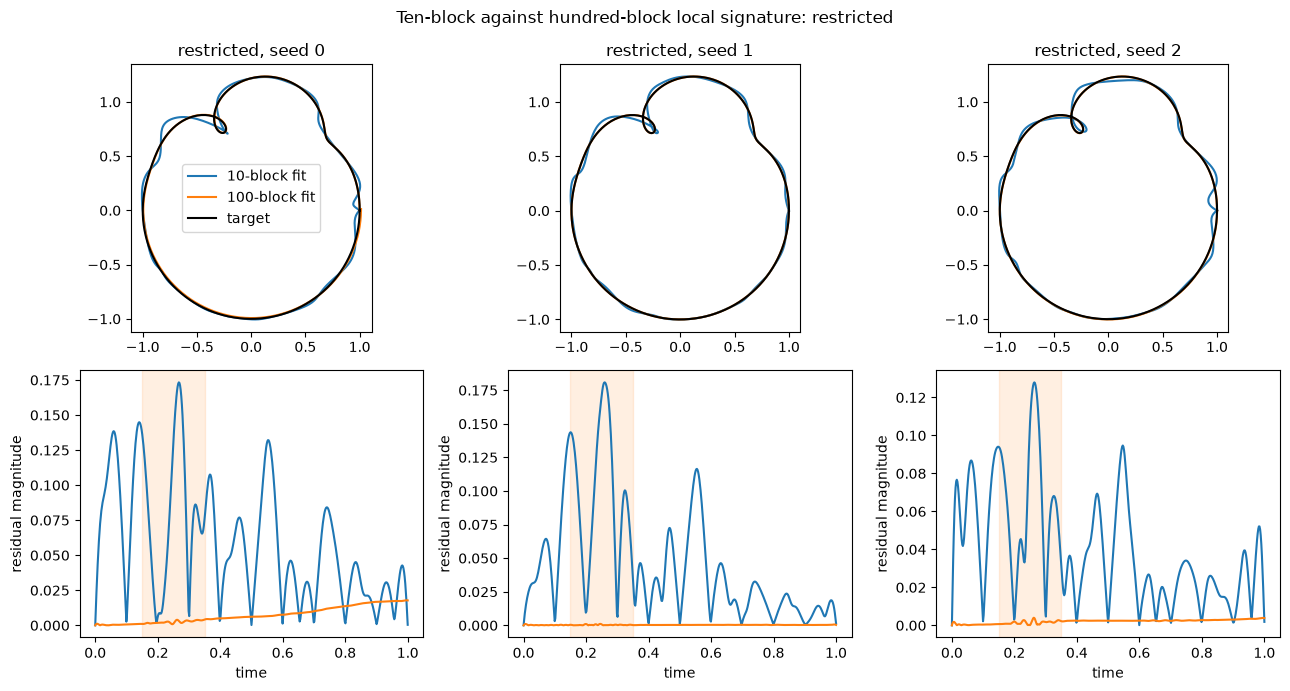

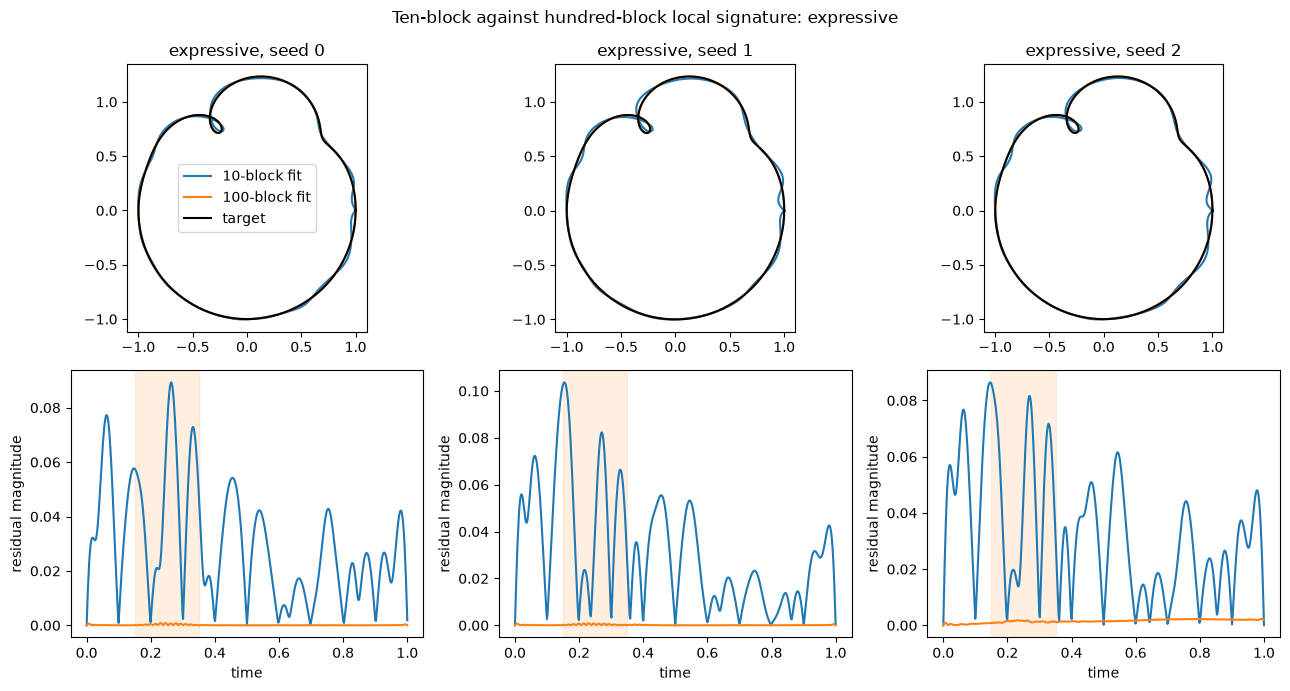

In [25]:
if refinement_status['complete']:
    import matplotlib.pyplot as plt

    colours = {'sig_local': 'tab:blue', 'sig_local_fine': 'tab:orange'}
    labels = {'sig_local': '10-block fit', 'sig_local_fine': '100-block fit'}
    for capacity in ['restricted', 'expressive']:
        figure, axes = plt.subplots(2, 3, figsize=(13, 7))
        for seed in [0, 1, 2]:
            group = refinement_comparison[
                (refinement_comparison.capacity == capacity)
                & (refinement_comparison.seed == seed)
            ]
            for loss in ['sig_local', 'sig_local_fine']:
                run_dir = Path(group[group.training_loss == loss].iloc[0].run_dir)
                if not run_dir.is_absolute():
                    run_dir = REPO_ROOT / run_dir
                arrays = np.load(run_dir / 'paths.npz')
                time = arrays['time']
                target = arrays['target']
                prediction = arrays['prediction']
                axes[0, seed].plot(
                    prediction[:, 0], prediction[:, 1],
                    color=colours[loss], label=labels[loss],
                )
                axes[1, seed].plot(
                    time, np.linalg.norm(prediction - target, axis=-1),
                    color=colours[loss], label=labels[loss],
                )
            axes[0, seed].plot(target[:, 0], target[:, 1], color='black', label='target')
            axes[0, seed].set_title(f'{capacity}, seed {seed}')
            axes[0, seed].set_aspect('equal')
            axes[1, seed].axvspan(0.15, 0.35, color='tab:orange', alpha=0.12)
            axes[1, seed].set_xlabel('time')
            axes[1, seed].set_ylabel('residual magnitude')
        axes[0, 0].legend()
        figure.suptitle(f'Ten-block against hundred-block local signature: {capacity}')
        figure.tight_layout()
        figure.savefig(analysis_root / f'path_comparison_{capacity}.png', dpi=160)
        plt.show()


In [26]:
if refinement_status['complete']:
    comparison_metrics = [
        'mse', 'j2', 'h1', 'linf', 'sig_global', 'local_j2',
        'sig_local_10', 'sig_local_100_scaled',
    ]
    pair_rows = []
    convergence_rows = []
    for (capacity, seed), group in refinement_comparison.groupby(['capacity', 'seed']):
        indexed = group.set_index('training_loss')
        pair_rows.append({
            'capacity': capacity,
            'seed': seed,
            **{metric: indexed.loc['sig_local_fine', metric]
               / indexed.loc['sig_local', metric]
               for metric in comparison_metrics},
        })
        run_dir = Path(indexed.loc['sig_local_fine', 'run_dir'])
        if not run_dir.is_absolute():
            run_dir = REPO_ROOT / run_dir
        train_values = pd.Series([
            row['train_loss']
            for row in json.loads((run_dir / 'history.json').read_text())
        ])
        convergence_rows.append({
            'capacity': capacity,
            'seed': seed,
            'late-window R': train_values.iloc[9500:10000].median()
                / train_values.iloc[9000:9500].median(),
        })

    paired_ratios = pd.DataFrame(pair_rows).set_index(['capacity', 'seed'])
    print('Ratio: hundred-block-trained metric / ten-block-trained metric; below one favours refinement.')
    display(paired_ratios)
    display(pd.DataFrame({
        'beats ten-block fit, groups out of 6': refinement_summary['fine_beats_local10_count'],
        'best among all six losses, groups out of 6': refinement_summary['fine_best_of_all_losses_count'],
    }))
    print('Late-window R below 0.95 means training loss was still decreasing at the fixed endpoint.')
    display(pd.DataFrame(convergence_rows).set_index(['capacity', 'seed']))
    print('sources:', analysis_root / 'comparison.csv', analysis_root / 'summary.json')


Ratio: hundred-block-trained metric / ten-block-trained metric; below one favours refinement.


mse        j2        h1      linf  sig_global  local_j2  \
capacity   seed                                                                 
expressive 0     0.000027  0.000027  0.000522  0.009307    0.000022  0.000055   
           1     0.000031  0.000031  0.000575  0.008182    0.000216  0.000057   
           2     0.001681  0.001678  0.000463  0.026705    0.123174  0.000683   
restricted 0     0.016737  0.016676  0.000977  0.103221    1.933358  0.000799   
           1     0.000032  0.000032  0.000312  0.005943    0.000558  0.000015   
           2     0.002242  0.002236  0.001435  0.031156    0.148788  0.000586   

                 sig_local_10  sig_local_100_scaled  
capacity   seed                                      
expressive 0         0.005496              0.000383  
           1         0.009214              0.000449  
           2         0.054105              0.000285  
restricted 0         0.156337              0.000358  
           1         0.006822              0.000218  
           2         0.056185              0.001005

,"beats ten-block fit, groups out of 6","best among all six losses, groups out of 6"
mse,6,3
j2,6,3
h1,6,2
linf,6,3
sig_global,5,3
local_j2,6,3
sig_local_10,6,4
sig_local_100_scaled,6,2


Late-window R below 0.95 means training loss was still decreasing at the fixed endpoint.


late-window R
capacity   seed               
expressive 0          0.707897
           1          0.530430
           2          0.931700
restricted 0          0.851614
           1          0.822171
           2          0.863664

sources: /Users/davin/Desktop/Pathwise Loss/pathwise-loss/results/runs/neural_ode_fixed_path_local_fine_10k/analysis/comparison.csv /Users/davin/Desktop/Pathwise Loss/pathwise-loss/results/runs/neural_ode_fixed_path_local_fine_10k/analysis/summary.json


### 22.7 Result and interpretation

All hundred-block fits completed with paired initialisation fingerprints. Relative to ten-block local-signature training, hundred-block training gives lower dense MSE, $J_2$, $H^1$, maximum error, burst-region $J_2$, ten-block local-signature discrepancy and scaled hundred-block discrepancy in every capacity-seed group. It also lowers global-signature discrepancy in all but one group. The adjacent ratio table and path plots reconstruct these comparisons from `results/runs/neural_ode_fixed_path_local_fine_10k/analysis/comparison.csv`; exact counts come from `analysis/summary.json`. The plot cell writes `analysis/path_comparison_{restricted,expressive}.png`.

Best objective varies across capacity-seed groups. The hundred-block fit is sometimes best among all objectives, while $H^1$ supplies lower values in several remaining groups; the preceding table calculates the exact per-metric counts. Since scaled hundred-block level one approaches a derivative penalty (§22.3), the comparison supports finer temporal localization without uniquely attributing improvement to higher signature levels.

Every hundred-block run has late-window ratio $R<0.95$, so its own training loss was still decreasing at 10,000 updates. Results describe one matched finite budget. They close Experiment A with a qualified finding: local partition is a material modelling choice, and coarse-block failure should not be read as evidence against local signatures.

## 23. Implementation and evidence map

- Target, Neural ODE, losses, training and dense evaluation: `../src/pathloss/fixed_path.py`
- Signature construction and anchored coordinate-mean loss: `../src/pathloss/signatures.py`
- Single-run and matrix runners: `../scripts/run_fixed_path.py`, `../scripts/run_fixed_path_study.py`
- Main configuration and results: `../configs/neural_ode_fixed_path_closeout_10k.yaml`, `../results/runs/neural_ode_fixed_path_closeout_10k/`
- Signature controls: `../results/runs/neural_ode_fixed_path_signature_10k/` and `../results/runs/neural_ode_fixed_path_budget_10k/`
- Learning-rate arm: `../configs/neural_ode_fixed_path_lr3e3.yaml`, `../results/runs/neural_ode_fixed_path_lr3e3/`
- Hundred-block refinement: `../configs/neural_ode_fixed_path_local_fine_10k.yaml`, `../results/runs/neural_ode_fixed_path_local_fine_10k/`
- Final refinement comparison and figures: `../results/runs/neural_ode_fixed_path_local_fine_10k/analysis/`

Sections 14 to 22 read these artifacts directly. Numerical claims are either calculated by an adjacent code cell or name the exact stored JSON/CSV file from which they are taken.
